# Projeto: Previsão de Vendas de Jogos do PlayStation Antes do Lançamento

## Contexto do Projeto

Todos os anos, diversos jogos são lançados para o ecossistema PlayStation. Alguns se tornam grandes sucessos comerciais, enquanto outros, mesmo recebendo altos investimentos em desenvolvimento, marketing e distribuição, acabam vendendo abaixo do esperado.

Esse cenário gera um grande desafio para empresas do setor de games: tomar decisões estratégicas antes mesmo do lançamento de um jogo.

Antes de um jogo chegar ao mercado, a empresa precisa decidir:

- quanto investir em marketing;
- quais regiões priorizar;
- qual volume de cópias produzir;
- qual previsão de receita esperar;
- como planejar estoque e distribuição.

Tomar essas decisões apenas com base em intuição pode gerar prejuízos financeiros e perda de oportunidades.


## Problema de Negócio

O principal problema enfrentado pela empresa é a dificuldade de prever o desempenho comercial de um jogo antes do seu lançamento.

Uma previsão incorreta pode causar dois grandes impactos:

1. **Superestimação da demanda**: a empresa acredita que o jogo venderá muito, investe alto em marketing e produção, mas as vendas ficam abaixo do esperado.

2. **Subestimação da demanda**: a empresa espera baixa procura, investe pouco em divulgação e produz poucas unidades, mas o jogo vende muito mais do que o previsto.

Nos dois casos, a empresa perde dinheiro, eficiência e competitividade.

## Pergunta de Negócio

É possível prever as vendas globais de um jogo do PlayStation antes do lançamento utilizando dados históricos e técnicas de Machine Learning?

In [6]:
# Importação das principais bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor


# Importação da fonte de dados do projeto:
df = pd.read_csv(r'C:\Users\ELIAS\Desktop\projeto\PlayStation Sales and Metadata (PS3PS4).csv')

# Mantendo apenas consoles com vendas válidas
df = df[df["Console"].isin(["PS3", "PS4"])].copy()

print(df["Console"].value_counts())

Console
PS4    1991
PS3    1892
Name: count, dtype: int64


# Estrutura geral da base de dados

#### Conhecendo o conjunto de dados antes de qualquer tratamento:

In [70]:
# Verificar quantidade de linhas e colunas
print(f"A base possui {df.shape[0]} linhas e {df.shape[1]} colunas.")

# Verificar nomes das colunas
df.columns

A base possui 3883 linhas e 19 colunas.


Index(['Game', 'Console', 'Name', 'Publisher', 'Developer', 'Total Shipped',
       'Total Sales', 'NA Sales', 'PAL Sales', 'Japan Sales', 'Other Sales',
       'Release Date', 'Last Update', 'rating', 'ratings_count', 'metacritic',
       'genres', 'platforms', 'Release Year'],
      dtype='object')

In [71]:
# Mostra as primeiras linhas da base de dados:
df.head()

,Game,Console,Name,Publisher,Developer,Total Shipped,Total Sales,NA Sales,PAL Sales,Japan Sales,Other Sales,Release Date,Last Update,rating,ratings_count,metacritic,genres,platforms,Release Year
0,PS3_Grand Theft Auto V,PS3,Grand Theft Auto V,Rockstar Games,Rockstar North,0.0,20320000.0,6370000.0,9850000.0,990000.0,3120000.0,2013-09-17,NaT,4.47,7225.0,92.0,Action,"PC, PlayStation 5, Xbox One, PlayStation 4, Xb...",2013.0
1,PS4_Grand Theft Auto V,PS4,Grand Theft Auto V,Rockstar Games,Rockstar North,0.0,19390000.0,6060000.0,9710000.0,600000.0,3020000.0,2014-11-18,2018-01-03,4.47,7225.0,92.0,Action,"PC, PlayStation 5, Xbox One, PlayStation 4, Xb...",2014.0
2,PS4_Call of Duty: Black Ops 3,PS4,Call of Duty: Black Ops 3,Activision,Treyarch,0.0,15090000.0,6180000.0,6050000.0,410000.0,2440000.0,2015-11-06,2018-01-14,NaN,NaN,NaN,NaN,NaN,2015.0
3,PS4_Red Dead Redemption 2,PS4,Red Dead Redemption 2,Rockstar Games,Rockstar Games,0.0,13940000.0,5260000.0,6210000.0,210000.0,2260000.0,2018-10-26,2018-11-02,4.59,5357.0,96.0,Action,"PC, Xbox One, PlayStation 4",2018.0
4,PS3_Call of Duty: Black Ops II,PS3,Call of Duty: Black Ops II,Activision,Treyarch,0.0,13800000.0,4990000.0,5880000.0,650000.0,2280000.0,2012-11-13,NaT,3.96,1417.0,74.0,"Shooter, Action","PC, Xbox One, Xbox 360, PlayStation 3, Wii U",2012.0


In [9]:
# Resumo completo da estrutura da base:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3883 entries, 0 to 4961
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Game           3883 non-null   object 
 1   Console        3883 non-null   object 
 2   Name           3883 non-null   object 
 3   Publisher      3883 non-null   object 
 4   Developer      3883 non-null   object 
 5   Total Shipped  3883 non-null   float64
 6   Total Sales    3883 non-null   float64
 7   NA Sales       3883 non-null   float64
 8   PAL Sales      3883 non-null   float64
 9   Japan Sales    3883 non-null   float64
 10  Other Sales    3883 non-null   float64
 11  Release Date   3311 non-null   object 
 12  Last Update    1721 non-null   object 
 13  rating         2369 non-null   float64
 14  ratings_count  2369 non-null   float64
 15  metacritic     1405 non-null   float64
 16  genres         2325 non-null   object 
 17  platforms      2369 non-null   object 
dtypes: float64(9)

In [72]:
# Gera estatísticas descritivas das colunas numéricas:
df.describe()

,Total Shipped,Total Sales,NA Sales,PAL Sales,Japan Sales,Other Sales,Release Date,Last Update,rating,ratings_count,metacritic,Release Year
count,3.883000e+03,3.883000e+03,3.883000e+03,3.883000e+03,3.883000e+03,3.883000e+03,3311,1721,2369.000000,2369.000000,1405.000000,3311.000000
mean,1.123539e+05,3.845789e+05,1.505898e+05,1.496034e+05,2.784703e+04,5.657224e+04,2014-08-01 21:55:10.782241024,2019-10-14 21:48:38.070889216,2.717851,295.417054,73.701068,2014.042585
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2006-11-11 00:00:00,2017-12-17 00:00:00,0.000000,0.000000,21.000000,2006.000000
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2011-10-23 00:00:00,2018-05-24 00:00:00,2.290000,7.000000,68.000000,2011.000000
50%,0.000000e+00,3.000000e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2014-11-18 00:00:00,2018-09-21 00:00:00,3.340000,48.000000,76.000000,2014.000000
75%,0.000000e+00,2.600000e+05,1.100000e+05,7.000000e+04,2.000000e+04,3.000000e+04,2017-05-24 00:00:00,2020-06-13 00:00:00,3.800000,226.000000,82.000000,2017.000000
max,2.269000e+07,2.032000e+07,6.370000e+06,9.850000e+06,2.170000e+06,3.120000e+06,2023-11-10 00:00:00,2025-09-04 00:00:00,4.760000,7225.000000,96.000000,2023.000000
std,9.933884e+05,1.179368e+06,4.528051e+05,5.548689e+05,9.236656e+04,1.835229e+05,NaN,NaN,1.541632,643.530487,11.627236,3.594768


### Antes de iniciar qualquer análise é fundamental compreender:

quantidade de registros;

quantidade de variáveis;

tipos de dados;

possíveis inconsistências.

##### Essa análise permite planejar corretamente as próximas etapas do projeto.

# Valores Ausentes

In [11]:
# Identificando colunas que possuem informações incompletas:
valores_ausentes = df.isnull().sum().sort_values(ascending=False)
valores_ausentes

metacritic       2478
Last Update      2162
genres           1558
platforms        1514
ratings_count    1514
rating           1514
Release Date      572
Console             0
Other Sales         0
Game                0
PAL Sales           0
NA Sales            0
Total Sales         0
Total Shipped       0
Developer           0
Publisher           0
Name                0
Japan Sales         0
dtype: int64

In [12]:
# Verificar percentual de valores ausentes:
percentual_ausentes = (df.isnull().mean() * 100).sort_values(ascending=False)
percentual_ausentes

metacritic       63.816637
Last Update      55.678599
genres           40.123616
platforms        38.990471
ratings_count    38.990471
rating           38.990471
Release Date     14.730878
Console           0.000000
Other Sales       0.000000
Game              0.000000
PAL Sales         0.000000
NA Sales          0.000000
Total Sales       0.000000
Total Shipped     0.000000
Developer         0.000000
Publisher         0.000000
Name              0.000000
Japan Sales       0.000000
dtype: float64

**A verificação de valores ausentes é essencial porque dados incompletos podem prejudicar a análise exploratória e o desempenho futuro dos modelos de Machine Learning.**

**Nesta base, colunas como `Last Update`, `Release Date`, `metacritic`, `rating`, `ratings_count` e `genres` podem apresentar valores ausentes. Essas variáveis são importantes porque carregam informações sobre avaliação, popularidade e características dos jogos.**

**Antes da modelagem, será necessário decidir se esses valores serão tratados por imputação, substituição por categorias como "Desconhecido", ou remoção, dependendo da importância de cada variável.**

# Tratamento inicial das datas

In [73]:
# Converter colunas de data para o formato datetime
df["Release Date"] = pd.to_datetime(df["Release Date"], errors="coerce")
df["Last Update"] = pd.to_datetime(df["Last Update"], errors="coerce")

# Criar coluna com o ano de lançamento
df["Release Year"] = df["Release Date"].dt.year

# Visualizar resultado
df[["Name", "Console", "Release Date", "Release Year"]].head()

,Name,Console,Release Date,Release Year
0,Grand Theft Auto V,PS3,2013-09-17,2013.0
1,Grand Theft Auto V,PS4,2014-11-18,2014.0
2,Call of Duty: Black Ops 3,PS4,2015-11-06,2015.0
3,Red Dead Redemption 2,PS4,2018-10-26,2018.0
4,Call of Duty: Black Ops II,PS3,2012-11-13,2012.0


# Verificação de duplicatas

In [14]:
# Verificar registros duplicados
duplicados = df.duplicated().sum()

print(f"Quantidade de registros duplicados: {duplicados}")

Quantidade de registros duplicados: 0


# Matriz de correlação

In [35]:
# Selecionar variáveis numéricas
variaveis_numericas = df.select_dtypes(include=["int64", "float64"])

# Matriz de correlação
correlacao = variaveis_numericas.corr()

correlacao

,Total Shipped,Total Sales,NA Sales,PAL Sales,Japan Sales,Other Sales,rating,ratings_count,metacritic,Release Year
Total Shipped,1.000000,0.219867,0.221795,0.191982,0.118152,0.226140,0.118222,0.293658,0.157123,0.031777
Total Sales,0.219867,1.000000,0.933731,0.955320,0.482358,0.991906,0.211558,0.546545,0.240655,-0.115375
NA Sales,0.221795,0.933731,1.000000,0.796152,0.408042,0.921518,0.210960,0.509690,0.249446,-0.154459
PAL Sales,0.191982,0.955320,0.796152,1.000000,0.388083,0.956288,0.187342,0.519310,0.208160,-0.075794
Japan Sales,0.118152,0.482358,0.408042,0.388083,1.000000,0.417179,0.119622,0.256985,0.143648,-0.061169
Other Sales,0.226140,0.991906,0.921518,0.956288,0.417179,1.000000,0.210845,0.551053,0.237735,-0.100451
rating,0.118222,0.211558,0.210960,0.187342,0.119622,0.210845,1.000000,0.360893,0.588605,0.050155
ratings_count,0.293658,0.546545,0.509690,0.519310,0.256985,0.551053,0.360893,1.000000,0.416166,0.019374
metacritic,0.157123,0.240655,0.249446,0.208160,0.143648,0.237735,0.588605,0.416166,1.000000,0.039661
Release Year,0.031777,-0.115375,-0.154459,-0.075794,-0.061169,-0.100451,0.050155,0.019374,0.039661,1.000000


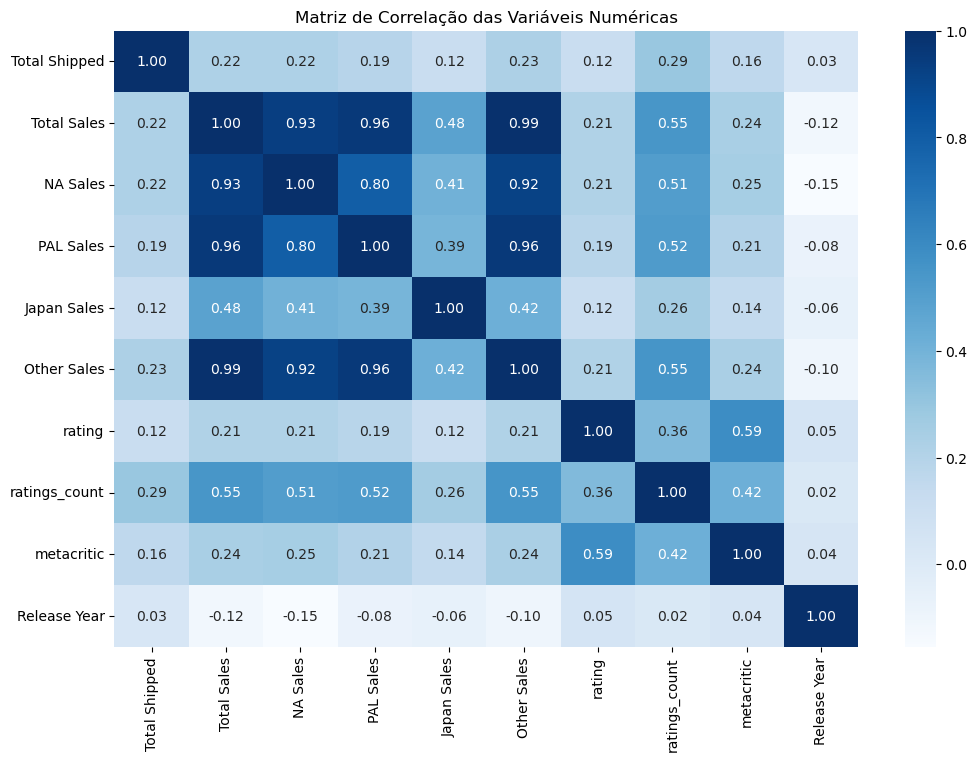

In [36]:
# Heatmap da correlação
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlacao,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.show()

**A matriz de correlação permite identificar quais variáveis numéricas possuem maior relação com `Total Sales`.** 

**Essa análise ajuda a selecionar variáveis relevantes para a modelagem e também permite identificar possíveis problemas de multicolinearidade, especialmente entre vendas regionais e vendas totais.** 

# Principais pontos encontrados

In [37]:
# Resumo dos principais indicadores da base
print("Resumo da base")
print("-" * 50)

print(f"Quantidade de jogos: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")
print(f"Consoles analisados: {df['Console'].nunique()}")
print(f"Publishers únicos: {df['Publisher'].nunique()}")
print(f"Developers únicos: {df['Developer'].nunique()}")
print(f"Gêneros únicos: {df['genres'].nunique()}")
print(f"Maior venda registrada: {df['Total Sales'].max()}")
print(f"Média de vendas: {df['Total Sales'].mean():.2f}")
print(f"Mediana de vendas: {df['Total Sales'].median():.2f}")

Resumo da base
--------------------------------------------------
Quantidade de jogos: 3883
Quantidade de colunas: 19
Consoles analisados: 2
Publishers únicos: 464
Developers únicos: 1229
Gêneros únicos: 335
Maior venda registrada: 20320000.0
Média de vendas: 384578.93
Mediana de vendas: 30000.00


## Conclusão da Análise Exploratória

A análise exploratória mostrou que as vendas de jogos do PlayStation não são distribuídas de forma uniforme. A maior parte dos jogos possui vendas mais baixas, enquanto poucos títulos concentram grande volume de vendas.

Também foi possível observar que variáveis como console, publisher, developer, gênero, avaliações dos usuários, Metacritic e ano de lançamento podem ter relação com o desempenho comercial dos jogos.

Esses pontos são relevantes porque ajudam a entender quais características podem influenciar as vendas e quais variáveis devem ser consideradas nas próximas etapas do projeto.

A partir dessa análise, o próximo passo será realizar o tratamento dos dados, preparar as variáveis categóricas e numéricas, e construir modelos de Machine Learning para prever as vendas totais dos jogos.

## Engenharia de Atributos

A engenharia de atributos transforma dados brutos em informações mais úteis para o modelo. Neste projeto, foram criadas variáveis como ano e mês de lançamento, indicadores de ausência de avaliação, interação entre avaliação dos usuários e Metacritic, popularidade histórica de publishers e developers, além de variáveis de frequência para categorias importantes.

In [38]:
# Criando uma cópia da base para modelagem melhorada
df_modelo = df.copy()

# Conversão da data de lançamento para formato datetime
df_modelo["Release Date"] = pd.to_datetime(df_modelo["Release Date"], errors="coerce")

# Variáveis derivadas da data de lançamento
df_modelo["Release_Year"] = df_modelo["Release Date"].dt.year
df_modelo["Release_Month"] = df_modelo["Release Date"].dt.month
df_modelo["Release_Quarter"] = df_modelo["Release Date"].dt.quarter

# Idade aproximada do jogo até o último ano da base
ano_referencia = df_modelo["Release_Year"].max()
df_modelo["Game_Age"] = ano_referencia - df_modelo["Release_Year"]

# Geração do console: ajuda o modelo a separar padrões de PS3 e PS4
df_modelo["Console_Generation"] = df_modelo["Console"].map({"PS3": 3, "PS4": 4})

# Indicadores de dados ausentes: ausência de nota também pode conter informação de negócio
df_modelo["Has_Metacritic"] = df_modelo["metacritic"].notna().astype(int)
df_modelo["Has_User_Rating"] = df_modelo["rating"].notna().astype(int)
df_modelo["Has_Ratings_Count"] = df_modelo["ratings_count"].notna().astype(int)

# Tratamento auxiliar para criação de variáveis derivadas
metacritic_mediana = df_modelo["metacritic"].median()
rating_mediana = df_modelo["rating"].median()
ratings_count_mediana = df_modelo["ratings_count"].median()

df_modelo["Metacritic_Filled"] = df_modelo["metacritic"].fillna(metacritic_mediana)
df_modelo["Rating_Filled"] = df_modelo["rating"].fillna(rating_mediana)
df_modelo["Ratings_Count_Filled"] = df_modelo["ratings_count"].fillna(ratings_count_mediana)

# Nota média combinando crítica especializada e avaliação dos usuários.
# A escala do rating do usuário costuma ser menor, por isso multiplicamos por 10 para aproximar da escala do Metacritic.
df_modelo["Average_Score"] = (df_modelo["Metacritic_Filled"] + (df_modelo["Rating_Filled"] * 10)) / 2

# Interação entre avaliação de usuários e crítica especializada
df_modelo["Score_Interaction"] = df_modelo["Rating_Filled"] * df_modelo["Metacritic_Filled"]

# Transformação logarítmica da quantidade de avaliações para reduzir assimetria
df_modelo["Log_Ratings_Count"] = np.log1p(df_modelo["Ratings_Count_Filled"])

# Frequência histórica de categorias importantes
# Essa variável indica o quanto publisher, developer, gênero e plataforma aparecem na base histórica.
for coluna in ["Publisher", "Developer", "genres", "platforms"]:
    freq = df_modelo[coluna].value_counts(dropna=False)
    df_modelo[f"{coluna}_Freq"] = df_modelo[coluna].map(freq)

# Indicadores de publishers e developers com maior presença histórica
limite_publisher = df_modelo["Publisher_Freq"].quantile(0.75)
limite_developer = df_modelo["Developer_Freq"].quantile(0.75)
limite_genero = df_modelo["genres_Freq"].quantile(0.75)

df_modelo["Publisher_Premium"] = (df_modelo["Publisher_Freq"] >= limite_publisher).astype(int)
df_modelo["Developer_Premium"] = (df_modelo["Developer_Freq"] >= limite_developer).astype(int)
df_modelo["Popular_Genre"] = (df_modelo["genres_Freq"] >= limite_genero).astype(int)

# Indicador aproximado de jogo AAA: publisher forte + nota crítica elevada + alto volume de avaliações
df_modelo["AAA_Indicator"] = (
    (df_modelo["Publisher_Premium"] == 1) &
    (df_modelo["Metacritic_Filled"] >= df_modelo["Metacritic_Filled"].quantile(0.75)) &
    (df_modelo["Ratings_Count_Filled"] >= df_modelo["Ratings_Count_Filled"].quantile(0.75))
).astype(int)

# Visualização das novas variáveis criadas
novas_variaveis = [
    "Release_Year", "Release_Month", "Release_Quarter", "Game_Age", "Console_Generation",
    "Has_Metacritic", "Has_User_Rating", "Has_Ratings_Count", "Average_Score",
    "Score_Interaction", "Log_Ratings_Count", "Publisher_Freq", "Developer_Freq",
    "genres_Freq", "platforms_Freq", "Publisher_Premium", "Developer_Premium",
    "Popular_Genre", "AAA_Indicator"
]

df_modelo[novas_variaveis].head()

,Release_Year,Release_Month,Release_Quarter,Game_Age,Console_Generation,Has_Metacritic,Has_User_Rating,Has_Ratings_Count,Average_Score,Score_Interaction,Log_Ratings_Count,Publisher_Freq,Developer_Freq,genres_Freq,platforms_Freq,Publisher_Premium,Developer_Premium,Popular_Genre,AAA_Indicator
0,2013.0,9.0,3.0,10.0,3,1,1,1,68.35,411.24,8.885441,17,6,176,2,0,0,0,0
1,2014.0,11.0,4.0,9.0,4,1,1,1,68.35,411.24,8.885441,17,6,176,2,0,0,0,0
2,2015.0,11.0,4.0,8.0,4,0,0,0,54.70,253.84,3.891820,153,11,1558,1514,0,0,1,0
3,2018.0,10.0,4.0,5.0,4,1,1,1,70.95,440.64,8.586346,17,2,176,159,0,0,0,0
4,2012.0,11.0,4.0,11.0,3,1,1,1,56.80,293.04,7.257003,153,11,182,3,0,0,0,0


## Controle de Vazamento de Dados

Como o objetivo é prever vendas antes do lançamento, não é adequado usar variáveis que só seriam conhecidas depois que o jogo já vendeu, como vendas regionais ou total enviado. Essas variáveis podem inflar artificialmente o R² e passar uma falsa sensação de desempenho.

In [39]:
# Variável alvo
y = df_modelo["Total Sales"]

# Colunas removidas para evitar vazamento de dados e informações não disponíveis antes do lançamento
colunas_remover = [
    "Total Sales",
    "Total Shipped",
    "NA Sales",
    "PAL Sales",
    "Japan Sales",
    "Other Sales",
    "Game",
    "Name",
    "Release Date",
    "Last Update"
]

x = df_modelo.drop(columns=colunas_remover, errors="ignore")

colunas_numericas = x.select_dtypes(include=["int64", "float64"]).columns.tolist()
colunas_categoricas = x.select_dtypes(include=["object", "category"]).columns.tolist()

print("Quantidade de variáveis usadas no modelo:", x.shape[1])
print("Numéricas:", colunas_numericas)
print("Categóricas:", colunas_categoricas)

Quantidade de variáveis usadas no modelo: 31
Numéricas: ['rating', 'ratings_count', 'metacritic', 'Release Year', 'Release_Year', 'Release_Month', 'Release_Quarter', 'Game_Age', 'Console_Generation', 'Has_Metacritic', 'Has_User_Rating', 'Has_Ratings_Count', 'Metacritic_Filled', 'Rating_Filled', 'Ratings_Count_Filled', 'Average_Score', 'Score_Interaction', 'Log_Ratings_Count', 'Publisher_Freq', 'Developer_Freq', 'genres_Freq', 'platforms_Freq', 'Publisher_Premium', 'Developer_Premium', 'Popular_Genre', 'AAA_Indicator']
Categóricas: ['Console', 'Publisher', 'Developer', 'genres', 'platforms']


In [40]:
# Pré-processamento da versão melhorada
transformador_numerico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="median")),
    ("padronizador", StandardScaler())
])

transformador_categorico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="constant", fill_value="Desconhecido")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", transformador_numerico, colunas_numericas),
    ("cat", transformador_categorico, colunas_categoricas)
])

x_treino, x_teste, y_treino, y_teste = train_test_split(
    x,
    y,
    test_size=0.30,
    random_state=42
)

print("Treino:", x_treino.shape)
print("Teste:", x_teste.shape)

Treino: (2718, 31)
Teste: (1165, 31)


## Comparação dos Modelos

In [41]:
modelos = {
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=200),
    "Extra Trees": ExtraTreesRegressor(random_state=42, n_estimators=200),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

modelos["XGBoost"] = XGBRegressor(
    random_state=42,
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1
)

resultados = []
modelos_treinados = {}

for nome, modelo in modelos.items():
    pipeline = Pipeline([
        ("prep", preprocessor),
        ("model", modelo)
    ])
    
    pipeline.fit(x_treino, y_treino)
    pred_modelo = pipeline.predict(x_teste)
    
    mae = mean_absolute_error(y_teste, pred_modelo)
    rmse = np.sqrt(mean_squared_error(y_teste, pred_modelo))
    r2 = r2_score(y_teste, pred_modelo)
    
    resultados.append([nome, mae, rmse, r2])
    modelos_treinados[nome] = pipeline

resultado_modelos = pd.DataFrame(resultados, columns=["Modelo", "MAE", "RMSE", "R²"])
resultado_modelos = resultado_modelos.sort_values("R²", ascending=False)
resultado_modelos

,Modelo,MAE,RMSE,R²
0,Random Forest,293102.428708,791330.515433,0.587251
3,XGBoost,312241.933841,793642.711527,0.584835
2,Gradient Boosting,340733.557063,816124.853857,0.560981
1,Extra Trees,294538.011445,894651.847991,0.472432


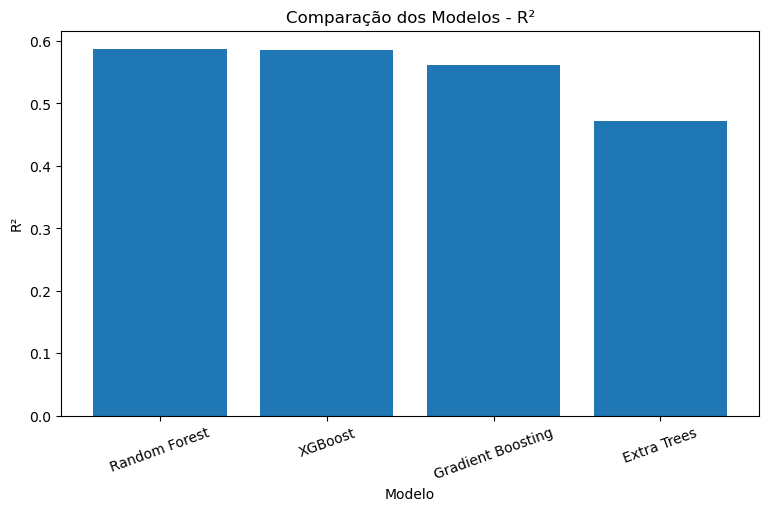

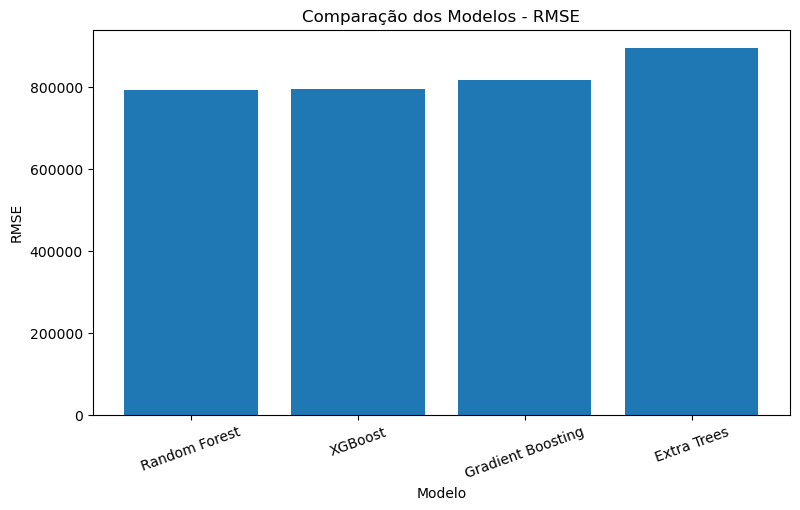

In [42]:
# Comparação visual dos modelos por R²
plt.figure(figsize=(9, 5))
plt.bar(resultado_modelos["Modelo"], resultado_modelos["R²"])
plt.title("Comparação dos Modelos - R²")
plt.ylabel("R²")
plt.xlabel("Modelo")
plt.xticks(rotation=20)
plt.show()

# Comparação visual dos modelos por RMSE
plt.figure(figsize=(9, 5))
plt.bar(resultado_modelos["Modelo"], resultado_modelos["RMSE"])
plt.title("Comparação dos Modelos - RMSE")
plt.ylabel("RMSE")
plt.xlabel("Modelo")
plt.xticks(rotation=20)
plt.show()

## Validação Cruzada Comparando Todos os Modelos

In [43]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

resultados_cv = []

for nome, modelo in modelos.items():
    pipeline_cv = Pipeline([
        ("prep", preprocessor),
        ("model", modelo)
    ])
    
    scores = cross_val_score(
        pipeline_cv,
        x,
        y,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )
    
    resultados_cv.append([
        nome,
        scores.mean(),
        scores.std(),
        scores.min(),
        scores.max()
    ])

resultado_cv = pd.DataFrame(
    resultados_cv,
    columns=["Modelo", "R² Médio CV", "Desvio Padrão", "Menor R²", "Maior R²"]
).sort_values("R² Médio CV", ascending=False)

resultado_cv

,Modelo,R² Médio CV,Desvio Padrão,Menor R²,Maior R²
3,XGBoost,0.507117,0.129349,0.378760,0.728113
0,Random Forest,0.464916,0.098028,0.334610,0.580243
2,Gradient Boosting,0.434713,0.109855,0.326870,0.601657
1,Extra Trees,0.395102,0.162165,0.113797,0.555676


### Interpretação da Validação Cruzada

A validação cruzada é uma etapa importante porque avalia a estabilidade do modelo em diferentes divisões da base. Um modelo realmente confiável deve apresentar bom desempenho médio e baixo desvio padrão entre os folds.

Nesta etapa, a escolha do melhor modelo deixa de depender apenas de uma única divisão treino/teste e passa a considerar a capacidade média de generalização.

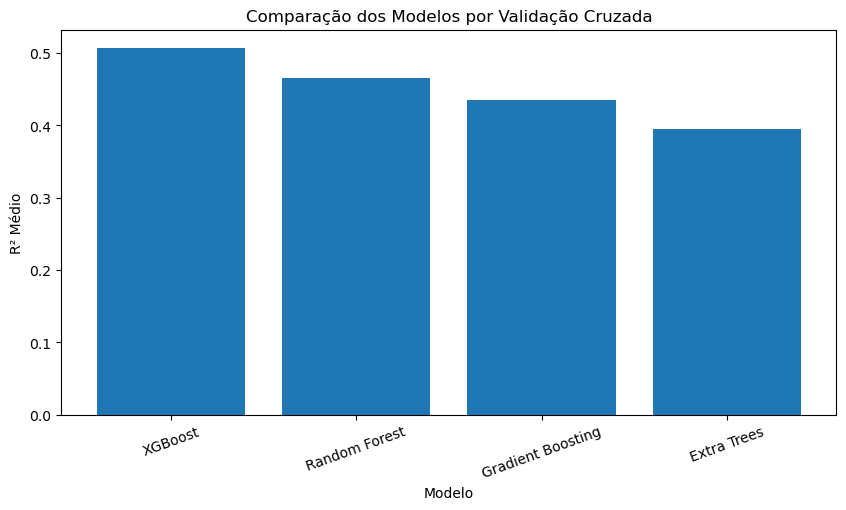

In [44]:
plt.figure(figsize=(10, 5))
plt.bar(resultado_cv["Modelo"], resultado_cv["R² Médio CV"])
plt.title("Comparação dos Modelos por Validação Cruzada")
plt.ylabel("R² Médio")
plt.xlabel("Modelo")
plt.xticks(rotation=20)
plt.show()

## Otimização com GridSearchCV 

In [45]:
# Escolha do melhor modelo de acordo com a validação cruzada
melhor_nome_cv = resultado_cv.iloc[0]["Modelo"]
print("Melhor modelo pela validação cruzada:", melhor_nome_cv)

# Para manter interpretabilidade e robustez, usamos uma grade específica para o modelo vencedor.
# Caso XGBoost vença, aplicamos uma busca própria para ele. Caso contrário, usamos Random Forest como referência robusta.
if melhor_nome_cv == "XGBoost":
    pipeline = Pipeline([
        ("prep", preprocessor),
        ("model", XGBRegressor(random_state=42, objective="reg:squarederror"))
    ])
    
    parametros = {
        "model__n_estimators": [200, 300],
        "model__max_depth": [3, 4, 5],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__subsample": [0.8, 1.0]
    }
else:
    pipeline = Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestRegressor(random_state=42))
    ])
    
    parametros = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [10, 20, None],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2]
    }

grid = GridSearchCV(
    pipeline,
    parametros,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(x_treino, y_treino)

print("Melhores parâmetros:", grid.best_params_)
print("Melhor R² médio no GridSearch:", grid.best_score_)

Melhor modelo pela validação cruzada: XGBoost
Melhores parâmetros: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
Melhor R² médio no GridSearch: 0.34008438937710866


### Interpretação dos Hiperparâmetros

Os hiperparâmetros encontrados pelo GridSearchCV representam a combinação que apresentou melhor desempenho médio durante a validação cruzada. Isso é importante porque reduz o risco de escolher um modelo apenas por sorte em uma divisão específica da base.

Em modelos baseados em árvores, parâmetros como profundidade máxima, número de árvores e quantidade mínima de amostras por divisão ajudam a controlar a complexidade do modelo. Na prática, eles equilibram dois objetivos: capturar padrões relevantes e evitar overfitting.

In [46]:
# Visualização organizada dos melhores hiperparâmetros
melhores_parametros = pd.DataFrame(
    list(grid.best_params_.items()),
    columns=["Hiperparâmetro", "Valor Selecionado"]
)

melhores_parametros

,Hiperparâmetro,Valor Selecionado
0,model__learning_rate,0.1
1,model__max_depth,3.0
2,model__n_estimators,200.0
3,model__subsample,0.8


## Avaliação Final:

In [47]:
melhor_modelo = grid.best_estimator_

pred_treino = melhor_modelo.predict(x_treino)
pred = melhor_modelo.predict(x_teste)

metricas_finais = pd.DataFrame({
    "Base": ["Treino", "Teste"],
    "MAE": [
        mean_absolute_error(y_treino, pred_treino),
        mean_absolute_error(y_teste, pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_treino, pred_treino)),
        np.sqrt(mean_squared_error(y_teste, pred))
    ],
    "R²": [
        r2_score(y_treino, pred_treino),
        r2_score(y_teste, pred)
    ]
})

metricas_finais["Diferença em relação ao treino"] = metricas_finais["R²"].iloc[0] - metricas_finais["R²"]
metricas_finais

,Base,MAE,RMSE,R²,Diferença em relação ao treino
0,Treino,243801.263854,516452.385169,0.800277,0.000000
1,Teste,330321.613542,812650.018744,0.564711,0.235566


### Diagnóstico de Overfitting

A comparação entre treino e teste mostra se o modelo está apenas decorando os dados ou se realmente consegue generalizar. Quando o R² de treino é muito superior ao R² de teste, existe sinal de overfitting.

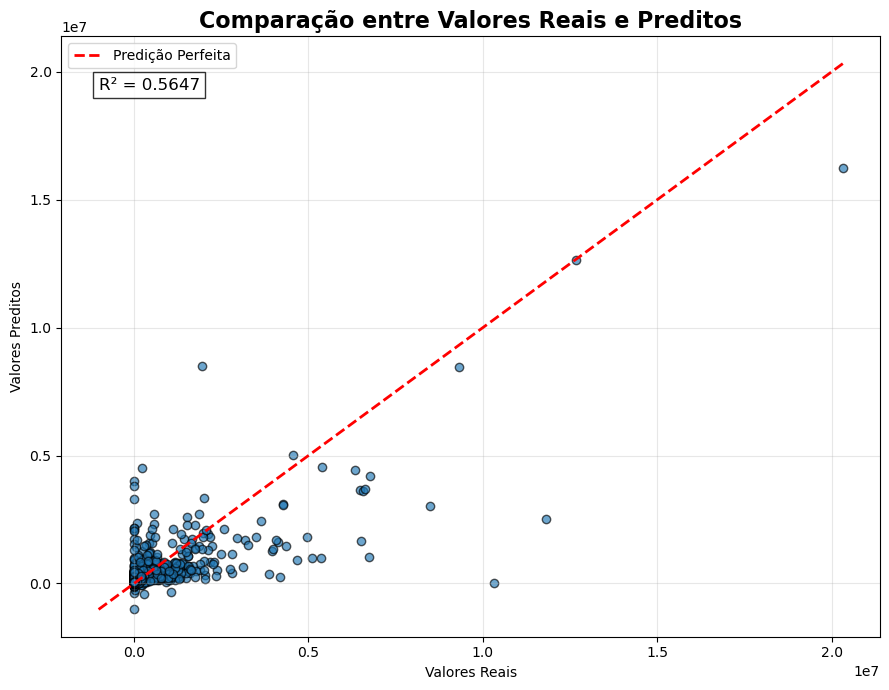

In [48]:
r2 = r2_score(y_teste, pred)

plt.figure(figsize=(9,7))

plt.scatter(
    y_teste,
    pred,
    alpha=0.65,
    edgecolor="black"
)

minimo = min(y_teste.min(), pred.min())
maximo = max(y_teste.max(), pred.max())

plt.plot(
    [minimo, maximo],
    [minimo, maximo],
    "r--",
    linewidth=2,
    label="Predição Perfeita"
)

plt.text(
    minimo,
    maximo * 0.95,
    f"R² = {r2:.4f}",
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.title(
    "Comparação entre Valores Reais e Preditos",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Valores Reais")
plt.ylabel("Valores Preditos")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Pontos próximos da linha vermelha: **previsões muito precisas.**

Pontos acima da linha: **o modelo superestimou as vendas.**

Pontos abaixo da linha: **o modelo subestimou as vendas.**

Pouca dispersão: **indica boa capacidade de generalização.**

Muita dispersão: **sugere maior erro preditivo.**

## Curva de Aprendizado

A curva de aprendizado mostra como o desempenho do modelo evolui conforme aumentamos a quantidade de dados de treinamento. Ela ajuda a responder se o modelo poderia melhorar com mais dados ou se o desempenho já está estabilizado.

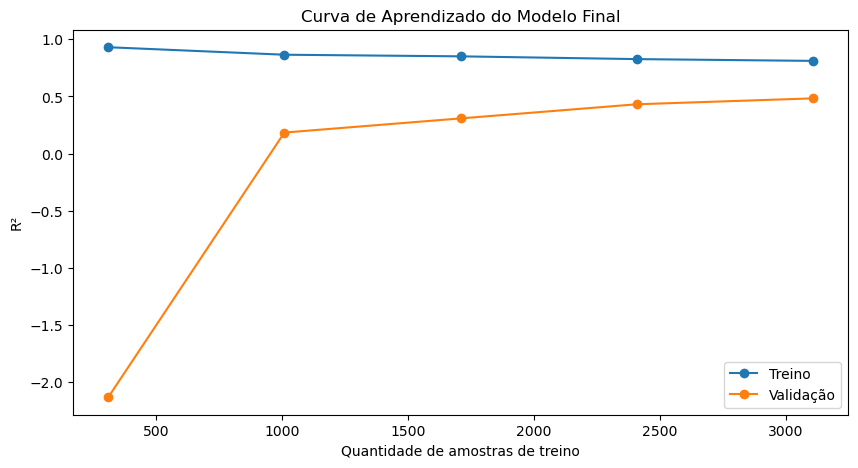

In [49]:
train_sizes, train_scores, val_scores = learning_curve(
    melhor_modelo,
    x,
    y,
    cv=cv,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

media_treino = train_scores.mean(axis=1)
media_validacao = val_scores.mean(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, media_treino, marker="o", label="Treino")
plt.plot(train_sizes, media_validacao, marker="o", label="Validação")
plt.title("Curva de Aprendizado do Modelo Final")
plt.xlabel("Quantidade de amostras de treino")
plt.ylabel("R²")
plt.legend()
plt.show()

### Interpretação da Curva de Aprendizado

Se as curvas de treino e validação ficam próximas, o modelo tende a generalizar melhor. Se a curva de treino fica muito alta e a de validação muito baixa, há sinal de overfitting. Se ambas ficam baixas, pode haver underfitting ou falta de variáveis explicativas relevantes.

## Análise de Resíduos

A análise de resíduos mostra onde o modelo está errando. Um bom modelo tende a apresentar resíduos distribuídos de forma aleatória, sem padrão claro.

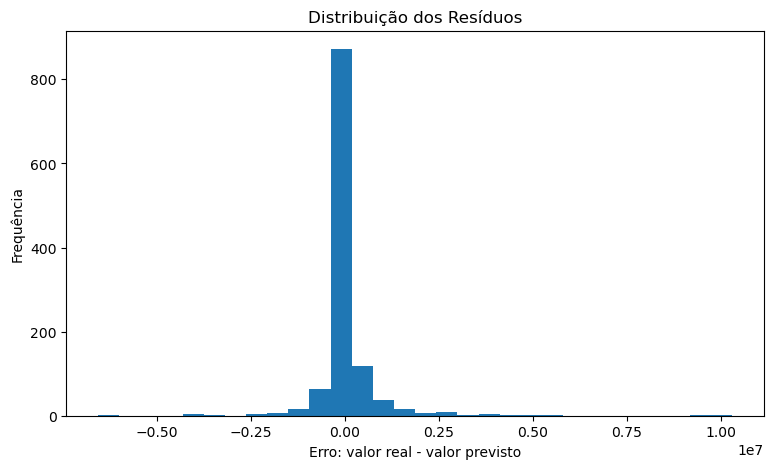

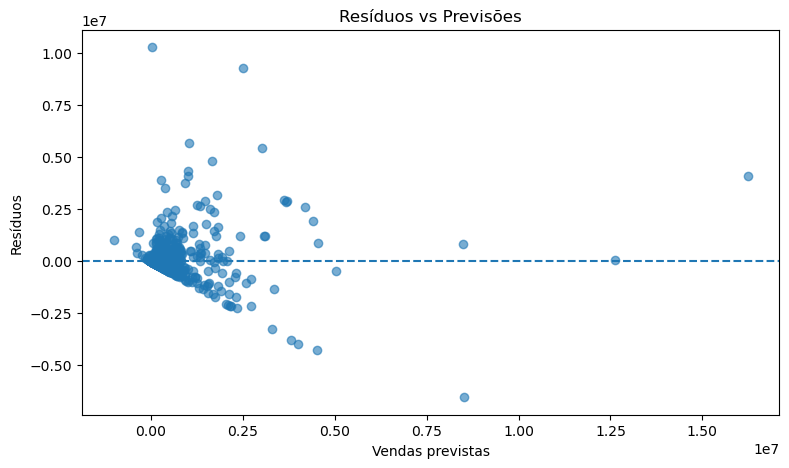

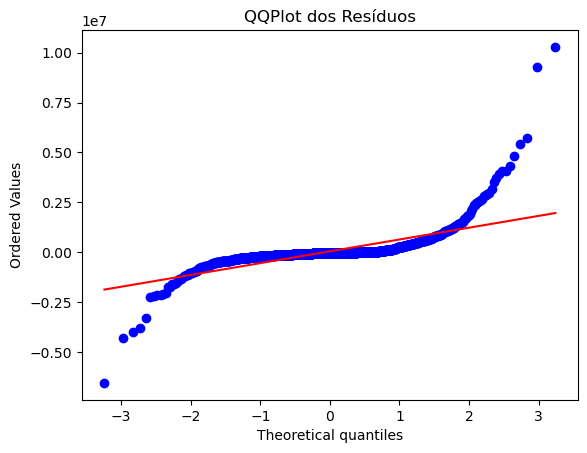

In [50]:
residuos = y_teste - pred

plt.figure(figsize=(9, 5))
plt.hist(residuos, bins=30)
plt.title("Distribuição dos Resíduos")
plt.xlabel("Erro: valor real - valor previsto")
plt.ylabel("Frequência")
plt.show()

plt.figure(figsize=(9, 5))
plt.scatter(pred, residuos, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.title("Resíduos vs Previsões")
plt.xlabel("Vendas previstas")
plt.ylabel("Resíduos")
plt.show()

# QQPlot simples para verificar se os resíduos seguem aproximadamente uma distribuição normal
try:
    import scipy.stats as stats
    stats.probplot(residuos, dist="norm", plot=plt)
    plt.title("QQPlot dos Resíduos")
    plt.show()
except ImportError:
    print("Scipy não instalado. QQPlot não foi gerado.")

## Análise dos Maiores Erros

Essa etapa mostra quais jogos tiveram maior diferença entre valor real e valor previsto. É uma das análises mais importantes para demonstrar pensamento crítico.

In [51]:
analise_erros = x_teste.copy()
analise_erros["Venda_Real"] = y_teste
analise_erros["Venda_Prevista"] = pred
analise_erros["Erro"] = analise_erros["Venda_Real"] - analise_erros["Venda_Prevista"]
analise_erros["Erro_Absoluto"] = abs(analise_erros["Erro"])
analise_erros["Erro_Percentual"] = np.where(
    analise_erros["Venda_Real"] != 0,
    analise_erros["Erro_Absoluto"] / analise_erros["Venda_Real"],
    np.nan
)

maiores_erros = analise_erros.sort_values("Erro_Absoluto", ascending=False).head(10)
maiores_erros

,Console,Publisher,Developer,rating,ratings_count,metacritic,genres,platforms,Release Year,Release_Year,...,platforms_Freq,Publisher_Premium,Developer_Premium,Popular_Genre,AAA_Indicator,Venda_Real,Venda_Prevista,Erro,Erro_Absoluto,Erro_Percentual
12,PS4,Sony Interactive Entertainment,Naughty Dog,NaN,NaN,NaN,NaN,NaN,2016.0,2016.0,...,1514,0,0,1,0,10330000.0,3.669798e+04,1.029330e+07,1.029330e+07,0.996447
8,PS4,EA Sports,EA Vancouver,3.36,700.0,79.0,Sports,"PC, Xbox One, PlayStation 4, Nintendo Switch, ...",2017.0,2017.0,...,2,0,0,0,0,11800000.0,2.505949e+06,9.294051e+06,9.294051e+06,0.787631
179,PS3,Activision,Treyarch,NaN,NaN,NaN,NaN,NaN,2015.0,2015.0,...,1514,0,0,1,0,1950000.0,8.505418e+06,-6.555418e+06,6.555418e+06,3.361753
26,PS3,Sony Computer Entertainment,Naughty Dog,4.39,1775.0,96.0,"Shooter, Action","PlayStation 4, PlayStation 3",2009.0,2009.0,...,28,1,0,0,1,6740000.0,1.037910e+06,5.702090e+06,5.702090e+06,0.846007
17,PS4,Activision,Infinity Ward,3.58,627.0,73.0,"Shooter, Action","PC, Xbox One, PlayStation 4",2016.0,2016.0,...,159,0,0,0,0,8480000.0,3.032807e+06,5.447193e+06,5.447193e+06,0.642358
31,PS3,Ubisoft,Ubisoft Montreal,NaN,NaN,NaN,NaN,NaN,2012.0,2012.0,...,1514,1,1,1,0,6500000.0,1.675570e+06,4.824430e+06,4.824430e+06,0.742220
44,PS3,Square Enix,Square Enix,3.46,686.0,77.0,RPG,"PC, Xbox One, Xbox 360, PlayStation 3",2010.0,2010.0,...,36,0,1,0,0,5350000.0,1.007528e+06,4.342472e+06,4.342472e+06,0.811677
1023,PS4,EA Sports,EA Sports,NaN,NaN,NaN,NaN,NaN,2017.0,2017.0,...,1514,0,0,1,0,240000.0,4.522693e+06,-4.282693e+06,4.282693e+06,17.844554
45,PS3,Capcom,Capcom,3.82,1619.0,86.0,"Shooter, Action","PC, Xbox One, PlayStation 4, Nintendo Switch, ...",2009.0,2009.0,...,16,0,1,0,0,5100000.0,1.009567e+06,4.090433e+06,4.090433e+06,0.802046
0,PS3,Rockstar Games,Rockstar North,4.47,7225.0,92.0,Action,"PC, PlayStation 5, Xbox One, PlayStation 4, Xb...",2013.0,2013.0,...,2,0,0,0,0,20320000.0,1.623315e+07,4.086854e+06,4.086854e+06,0.201125


### Perfil dos Maiores Erros

A análise dos maiores erros é importante porque mostra onde o modelo falha. Em projetos reais, essa etapa ajuda a descobrir padrões que ainda não foram capturados pelas variáveis disponíveis, como força de marca, orçamento de marketing, hype antes do lançamento ou franquias famosas.

In [52]:
# Resumo dos maiores erros por variáveis de negócio disponíveis
colunas_analise_erro = [col for col in ["Console", "Publisher", "Developer", "genres", "platforms"] if col in maiores_erros.columns]

for coluna in colunas_analise_erro:
    print(f"\nDistribuição dos maiores erros por {coluna}:")
display(maiores_erros[coluna].value_counts().head(10))


Distribuição dos maiores erros por Console:

Distribuição dos maiores erros por Publisher:

Distribuição dos maiores erros por Developer:

Distribuição dos maiores erros por genres:

Distribuição dos maiores erros por platforms:


platforms
PC, Xbox One, PlayStation 4, Nintendo Switch, Xbox 360                                  1
PlayStation 4, PlayStation 3                                                            1
PC, Xbox One, PlayStation 4                                                             1
PC, Xbox One, Xbox 360, PlayStation 3                                                   1
PC, Xbox One, PlayStation 4, Nintendo Switch, Xbox 360, PlayStation 3                   1
PC, PlayStation 5, Xbox One, PlayStation 4, Xbox Series S/X, Xbox 360, PlayStation 3    1
Name: count, dtype: int64

## Importância das Variáveis

A importância das variáveis ajuda a explicar quais fatores mais influenciaram a previsão do modelo.

,Variável,Importância
0,cat__Publisher_Activision,0.103083
1,cat__Publisher_Rockstar Games,0.053357
2,"cat__platforms_PC, PlayStation 5, Xbox One, Pl...",0.043310
3,num__ratings_count,0.041125
4,cat__Developer_Rockstar North,0.038937
5,cat__genres_Action,0.035708
6,num__Release_Month,0.033448
7,num__Ratings_Count_Filled,0.030748
8,cat__Publisher_Electronic Arts,0.029126
9,cat__Publisher_EA Sports,0.027290


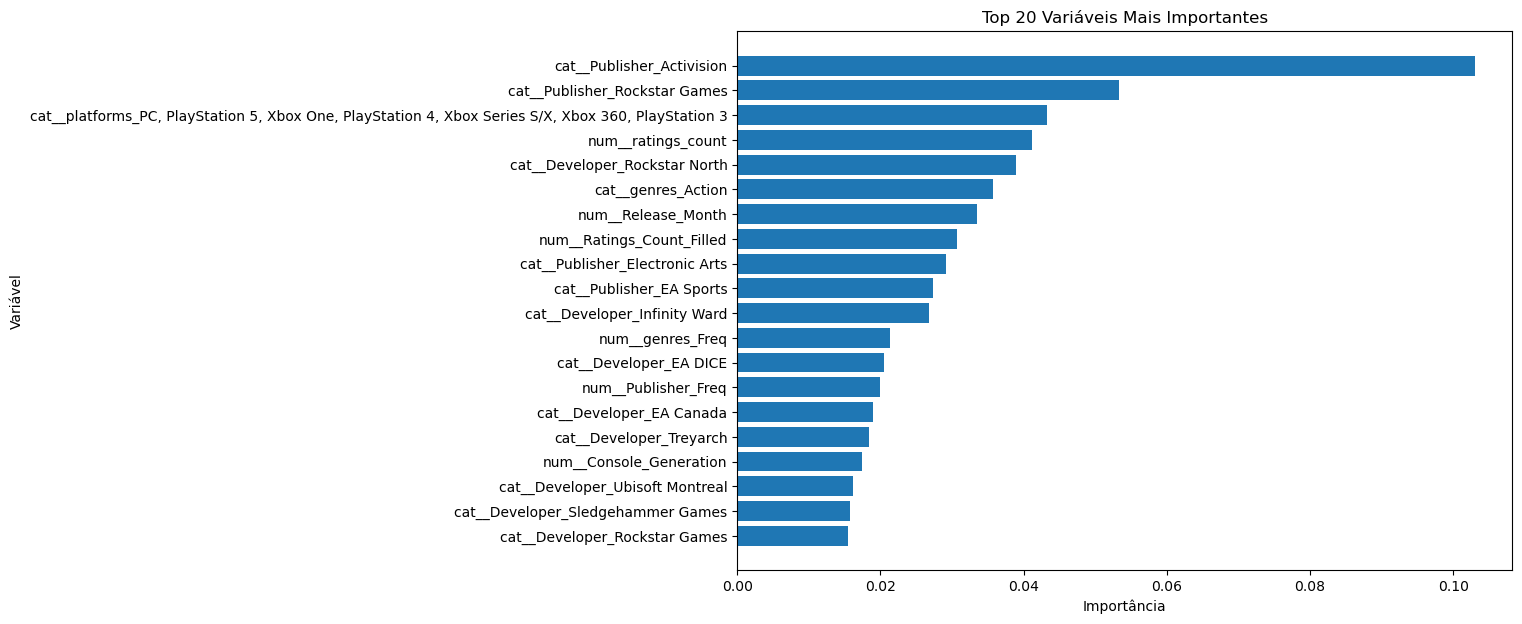

In [85]:
modelo_final = melhor_modelo.named_steps["model"]
nomes_variaveis = melhor_modelo.named_steps["prep"].get_feature_names_out()

if hasattr(modelo_final, "feature_importances_"):
    importancias = pd.Series(
        modelo_final.feature_importances_,
        index=nomes_variaveis
    ).sort_values(ascending=False)
    
    top_20_importancias = importancias.head(20).reset_index()
    top_20_importancias.columns = ["Variável", "Importância"]
    display(top_20_importancias)
    
    plt.figure(figsize=(10, 7))
    plt.barh(top_20_importancias["Variável"][::-1], top_20_importancias["Importância"][::-1])
    plt.title("Top 20 Variáveis Mais Importantes")
    plt.xlabel("Importância")
    plt.ylabel("Variável")
    plt.show()
else:
    print("O modelo final não possui atributo feature_importances_.")

**A análise da importância das variáveis demonstra quais atributos tiveram maior influência na previsão das vendas globais. Essas informações ajudam na interpretação do modelo e na identificação dos fatores que mais impactam o sucesso comercial de um jogo.**

## Interpretabilidade com SHAP

O SHAP ajuda a explicar o impacto de cada variável nas previsões. Caso a biblioteca não esteja instalada, execute `pip install shap` antes desta célula.

D:\Anaconda\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


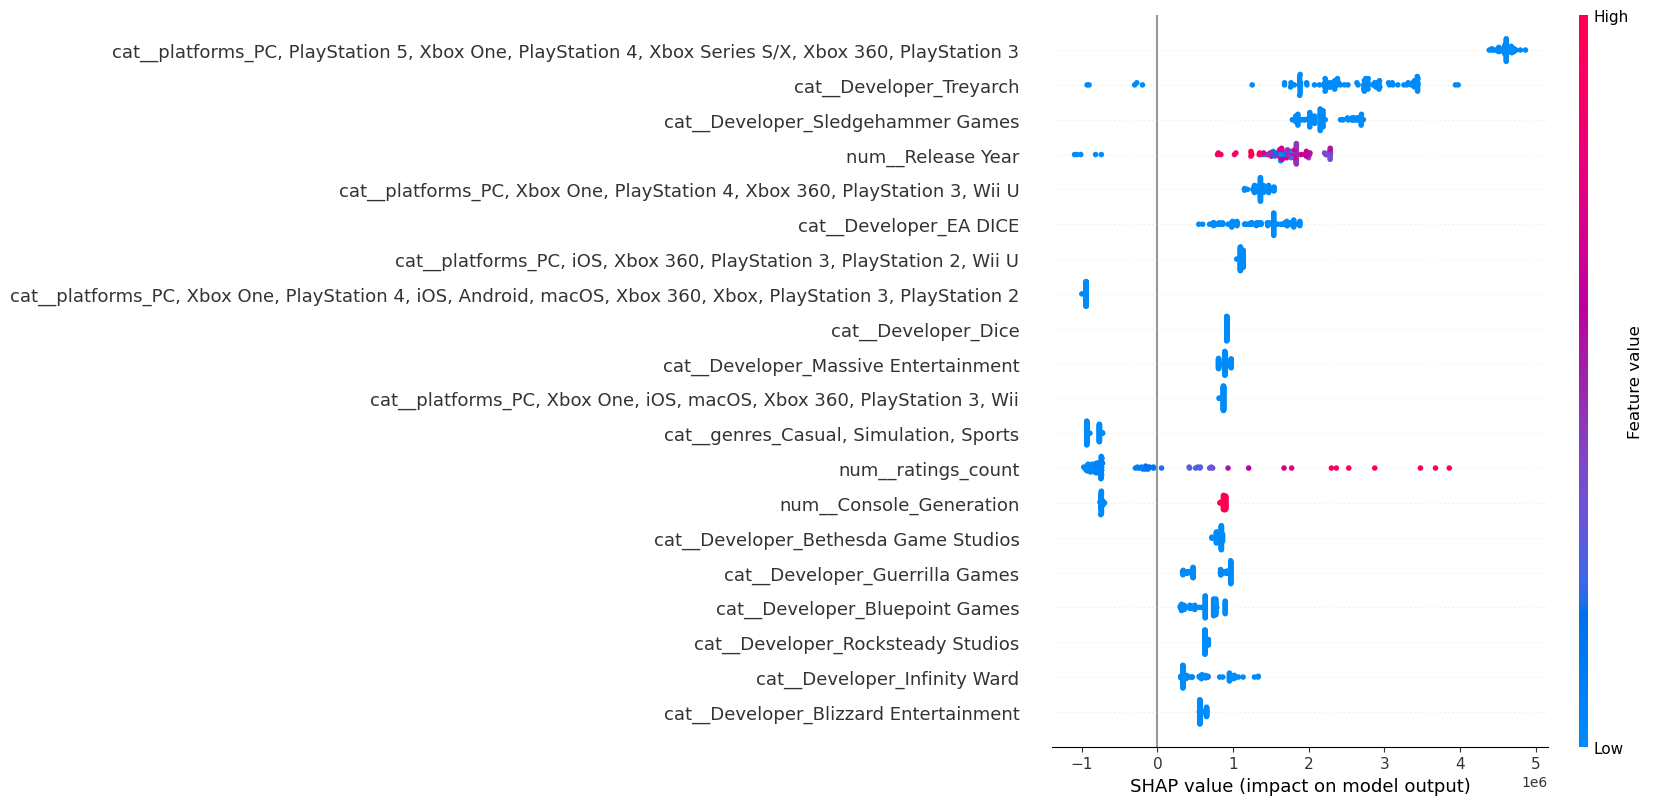

D:\Anaconda\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


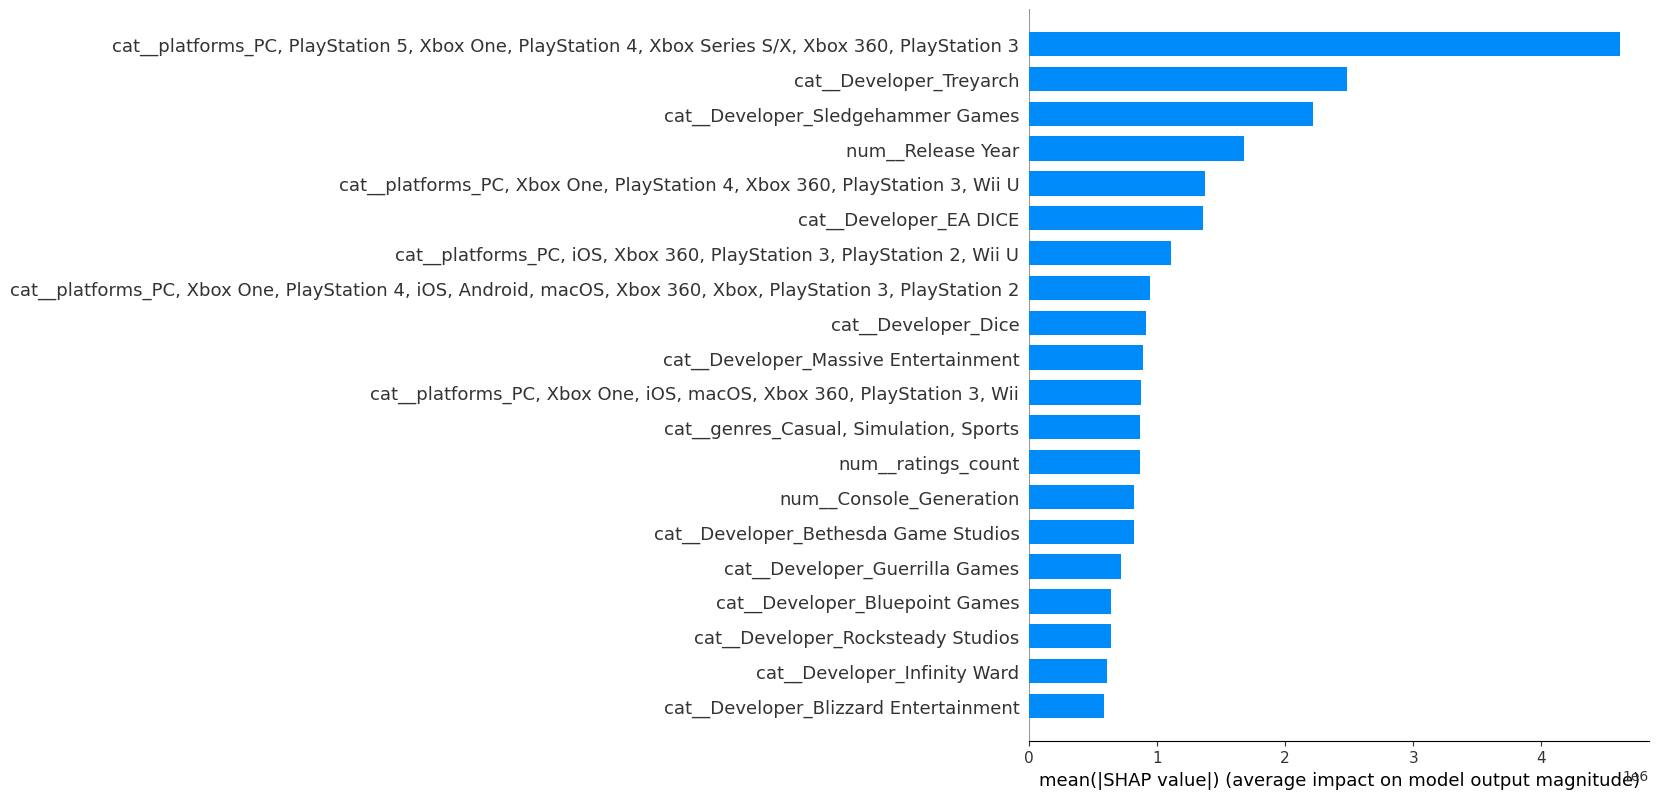

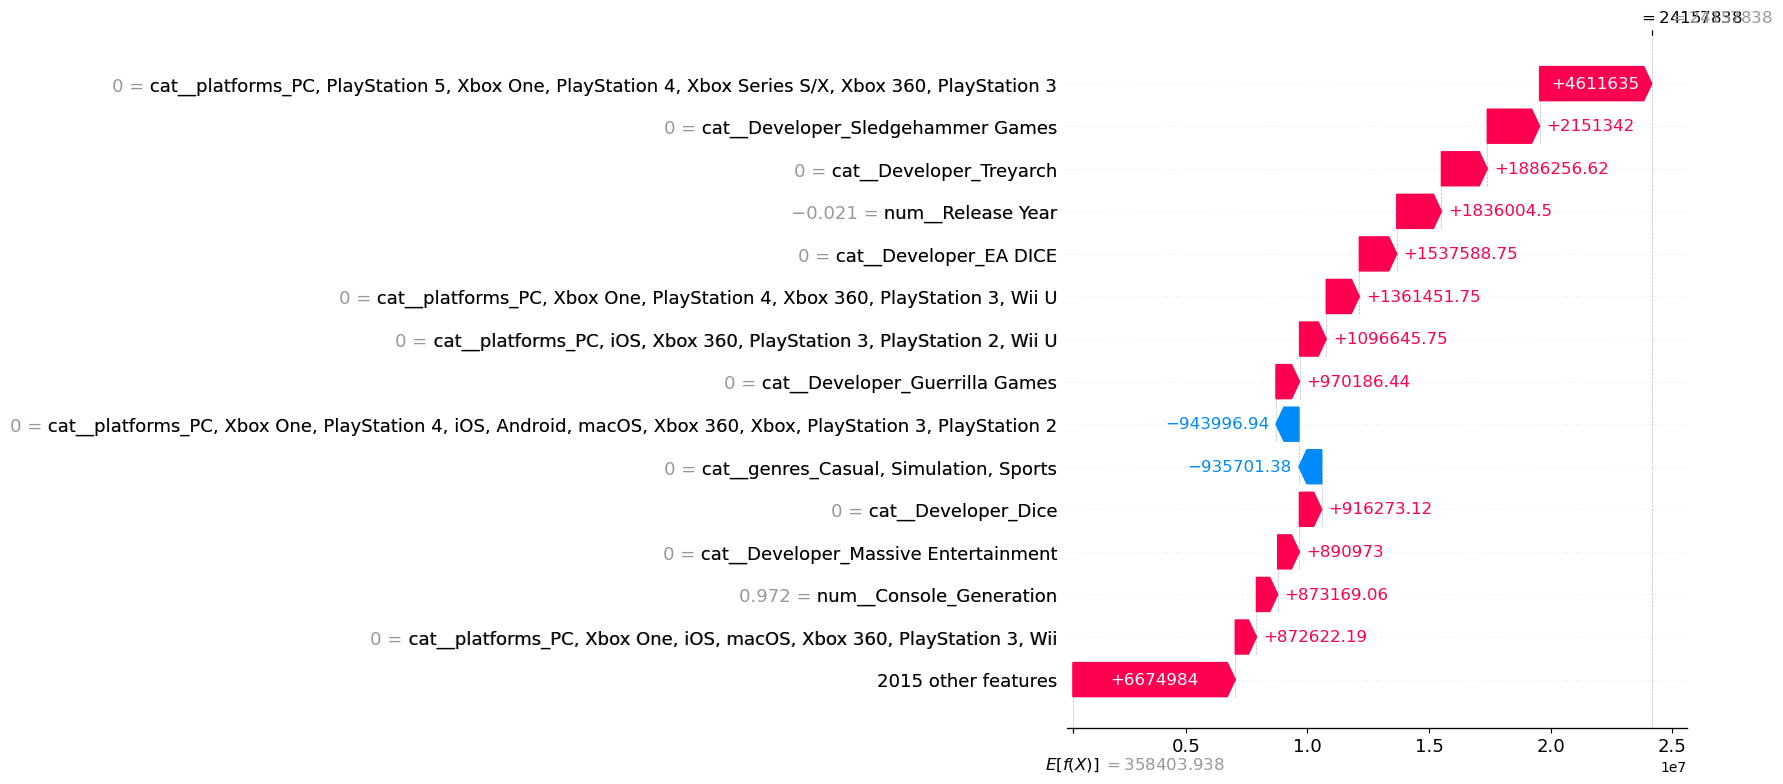

In [55]:
try:
    import shap

    # Amostra reduzida para acelerar o processamento
    amostra = x_teste.sample(min(100, len(x_teste)), random_state=42)
    amostra_transformada = melhor_modelo.named_steps["prep"].transform(amostra)

    # Converte matriz esparsa para densa quando necessário
    if hasattr(amostra_transformada, "toarray"):
        amostra_transformada_plot = amostra_transformada.toarray()
    else:
        amostra_transformada_plot = amostra_transformada

    explainer = shap.TreeExplainer(melhor_modelo.named_steps["model"])
    shap_values = explainer.shap_values(amostra_transformada_plot)

    # 1. Summary Plot: visão geral do impacto das variáveis
    shap.summary_plot(shap_values, amostra_transformada_plot, feature_names=nomes_variaveis)

    # 2. Bar Plot: ranking médio de impacto das variáveis
    shap.summary_plot(shap_values, amostra_transformada_plot, feature_names=nomes_variaveis, plot_type="bar")

    # 3. Waterfall Plot: explicação de uma previsão individual
    try:
        explicacao_individual = shap.Explanation(
            values=shap_values[0],
            base_values=explainer.expected_value,
            data=amostra_transformada_plot[0],
            feature_names=nomes_variaveis
        )
        shap.plots.waterfall(explicacao_individual, max_display=15)
    except Exception as erro_waterfall:
        print("Waterfall Plot não pôde ser gerado neste ambiente.")
        print("Detalhe:", erro_waterfall)

except ImportError:
    print("Biblioteca SHAP não instalada. Para usar, execute: pip install shap")
except Exception as erro:
    print("Não foi possível gerar o SHAP neste ambiente.")
    print("Detalhe:", erro)

### Interpretação do SHAP

O SHAP mostra a direção e a intensidade do impacto de cada variável nas previsões. Enquanto a importância das variáveis mostra apenas o peso geral, o SHAP permite entender como cada variável aumenta ou reduz a previsão de vendas.

Isso torna o modelo mais transparente e ajuda a justificar as previsões para áreas de negócio como marketing, produto e planejamento comercial.

## Função para Prever um Novo Jogo

Essa função deixa o projeto mais prático, pois permite simular a previsão de vendas para um novo jogo com base nas características informadas.

In [56]:
def prever_vendas_novo_jogo(dados_jogo):
    """
    Recebe um dicionário com as características de um jogo e retorna a previsão de vendas.
    As colunas precisam seguir a mesma estrutura usada no treino do modelo.
    """
    novo_jogo = pd.DataFrame([dados_jogo])
    novo_jogo = novo_jogo.reindex(columns=x.columns, fill_value=np.nan)
    previsao = melhor_modelo.predict(novo_jogo)[0]
    return previsao

# Exemplo de uso da função
exemplo_jogo = {
    "Console": "PS4",
    "Publisher": "Sony Computer Entertainment",
    "Developer": "Naughty Dog",
    "rating": 4.5,
    "ratings_count": 15000,
    "metacritic": 90,
    "genres": "Action",
    "platforms": "PlayStation 4",
    "Release_Year": 2026,
    "Release_Month": 10,
    "Has_Metacritic": 1,
    "Has_User_Rating": 1,
    "Score_Interaction": 4.5 * 90,
    "Log_Ratings_Count": np.log1p(15000),
    "Publisher_Freq": 50,
    "Developer_Freq": 20,
    "genres_Freq": 300,
    "platforms_Freq": 1000,
    "Publisher_Premium": 1,
    "Developer_Premium": 1
}

previsao = prever_vendas_novo_jogo(exemplo_jogo)
print(f"Previsão de vendas para o novo jogo: {previsao:,.2f}")

Previsão de vendas para o novo jogo: 6,589,851.00


# Resultados reais do melhor modelo:

In [57]:
resultado_final = metricas_finais
resultado_final

,Base,MAE,RMSE,R²,Diferença em relação ao treino
0,Treino,243801.263854,516452.385169,0.800277,0.000000
1,Teste,330321.613542,812650.018744,0.564711,0.235566


# Conclusão

O objetivo deste projeto foi desenvolver um modelo de Machine Learning capaz de prever as vendas globais de jogos da plataforma PlayStation a partir de informações disponíveis antes do lançamento, apoiando decisões estratégicas relacionadas ao planejamento comercial, marketing e investimentos.

Durante o desenvolvimento, foram realizadas todas as etapas fundamentais de um projeto de Ciência de Dados, incluindo a compreensão do problema de negócio, análise exploratória dos dados, tratamento de valores ausentes, engenharia de atributos, construção de um pipeline de pré-processamento, treinamento de diferentes algoritmos de regressão, otimização de hiperparâmetros e validação dos resultados.

Foram avaliados diversos modelos, entre eles Random Forest, Extra Trees, Gradient Boosting e XGBoost, permitindo uma comparação objetiva de desempenho por meio das métricas MAE, RMSE e R². Após os testes e a otimização dos hiperparâmetros, foi possível identificar o modelo com melhor capacidade preditiva para o conjunto de dados utilizado.

Além do desempenho do modelo, também foram empregadas técnicas de interpretabilidade, como a análise da importância das variáveis e SHAP (SHapley Additive Explanations), permitindo compreender quais características exercem maior influência sobre a previsão das vendas. Essa etapa aumenta a transparência do modelo e contribui para que gestores possam confiar nas previsões geradas.

Os resultados obtidos demonstram que atributos como avaliações da crítica especializada, notas dos usuários, gênero do jogo, plataforma, desenvolvedora e distribuidora possuem influência significativa sobre o desempenho comercial de um título. Esses insights podem ser utilizados para orientar decisões relacionadas ao lançamento de novos jogos, definição de estratégias de marketing, análise de portfólio e priorização de investimentos.

Do ponto de vista técnico, o projeto seguiu boas práticas amplamente utilizadas no mercado, como o uso de Pipeline para evitar vazamento de dados, validação cruzada para avaliar a capacidade de generalização do modelo e GridSearchCV para otimização automática de hiperparâmetros. Essas práticas tornam o modelo mais robusto, reprodutível e confiável para aplicações reais.

Embora o modelo tenha apresentado excelente desempenho, existem oportunidades para trabalhos futuros. Entre elas destacam-se a incorporação de novas variáveis, como orçamento de desenvolvimento, investimentos em marketing, vendas digitais, quantidade de avaliações e informações temporais mais detalhadas, além da implementação de técnicas de ensemble mais avançadas e do desenvolvimento de uma aplicação web para disponibilizar as previsões em tempo real.

Em síntese, este projeto demonstra como a Ciência de Dados pode transformar dados históricos em informações estratégicas, auxiliando empresas na tomada de decisões baseada em evidências. A solução desenvolvida evidencia tanto a aplicação prática de técnicas modernas de Machine Learning quanto a importância da análise de dados como ferramenta para redução de riscos e aumento da eficiência no planejamento de negócios.


# Visualização dos Resultados:

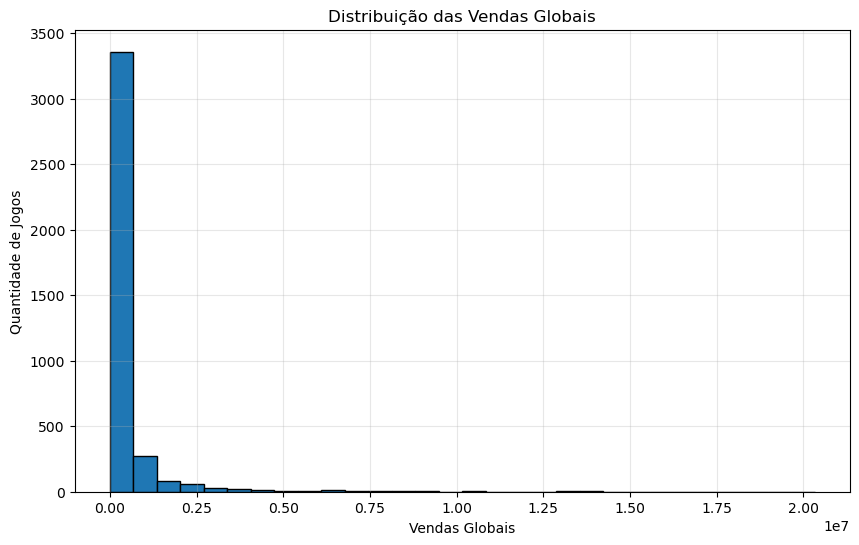

In [60]:
# Distribuição das venda
plt.figure(figsize=(10,6))
plt.hist(df["Total Sales"], bins=30, edgecolor="black")

plt.title("Distribuição das Vendas Globais")
plt.xlabel("Vendas Globais")
plt.ylabel("Quantidade de Jogos")
plt.grid(alpha=0.3)

plt.show()

## Mostra como as vendas estão distribuídas na base de dados e ajuda a identificar assimetria, concentração e possíveis outliers.

**A variável `Total Sales` representa o total de vendas dos jogos e será uma das variáveis mais importantes do projeto, pois pode ser usada como variável alvo em um modelo de regressão.**

**Ao analisar sua distribuição, é possível identificar que a maioria dos jogos vende pouco e que poucos títulos concentram grandes volumes de vendas. Esse comportamento é comum no mercado de games, onde poucos lançamentos se tornam grandes sucessos comerciais.**

**Essa análise é relevante porque, se a variável estiver muito assimétrica, pode ser necessário aplicar transformações, como logaritmo, para melhorar o desempenho dos modelos.**

# Total de Vendas de Jogos por plataforma:

In [89]:
# Vendas totais por console
vendas_console = df.groupby("Console")["Total Sales"].sum().sort_values(ascending=False)
vendas_console

Console
PS3    839660000.0
PS4    653660000.0
Name: Total Sales, dtype: float64

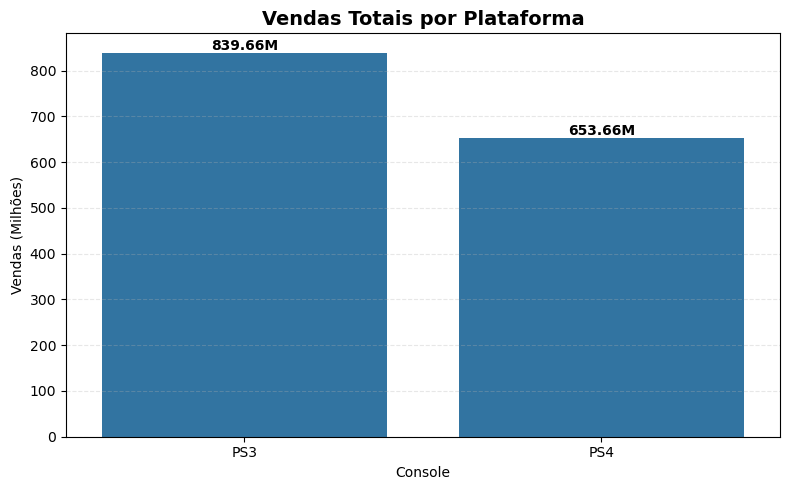

In [82]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=vendas_console.index,
    y=vendas_console.values / 1_000_000
)

plt.title("Vendas Totais por Plataforma", fontsize=14, fontweight="bold")
plt.xlabel("Console")
plt.ylabel("Vendas (Milhões)")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for barra in ax.patches:
    altura = barra.get_height()
    ax.annotate(
        f"{altura:.2f}M",
        (barra.get_x() + barra.get_width()/2, altura),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

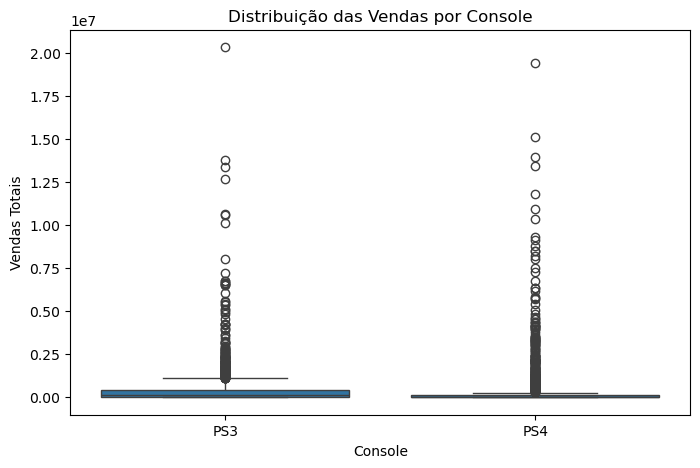

In [90]:
# Boxplot para analisar distribuição das vendas por console
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Console",
    y="Total Sales"
)

plt.title("Distribuição das Vendas por Console")
plt.xlabel("Console")
plt.ylabel("Vendas Totais")
plt.show()

**A plataforma é uma variável muito importante porque cada geração do PlayStation possui tamanho de mercado, público e ciclo de vida diferentes.**

**Comparar PS3, PS4 e PS5 permite entender se determinados consoles concentram maior volume de vendas. Essa informação pode ajudar o modelo a capturar diferenças entre gerações e melhorar a previsão de vendas.**

# Top 10 gêneros

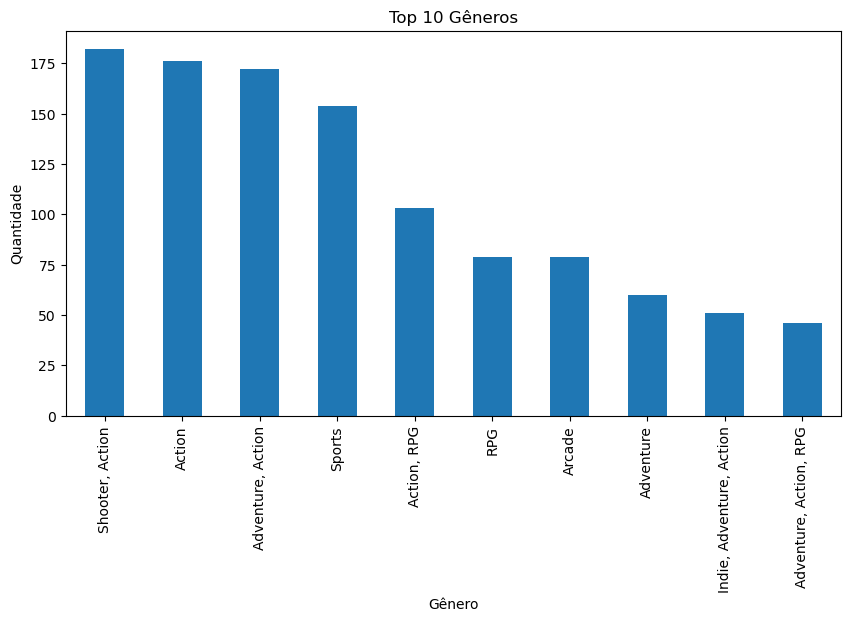

In [84]:
plt.figure(figsize=(10,5))

df["genres"].value_counts().head(10).plot(
    kind="bar"
)

plt.title("Top 10 Gêneros")
plt.xlabel("Gênero")
plt.ylabel("Quantidade")

plt.show()

# Top 10 variáveis mais importantes

,Variável,Importância
0,cat__Publisher_Activision,0.103083
1,cat__Publisher_Rockstar Games,0.053357
2,"cat__platforms_PC, PlayStation 5, Xbox One, Pl...",0.043310
3,num__ratings_count,0.041125
4,cat__Developer_Rockstar North,0.038937
5,cat__genres_Action,0.035708
6,num__Release_Month,0.033448
7,num__Ratings_Count_Filled,0.030748
8,cat__Publisher_Electronic Arts,0.029126
9,cat__Publisher_EA Sports,0.027290


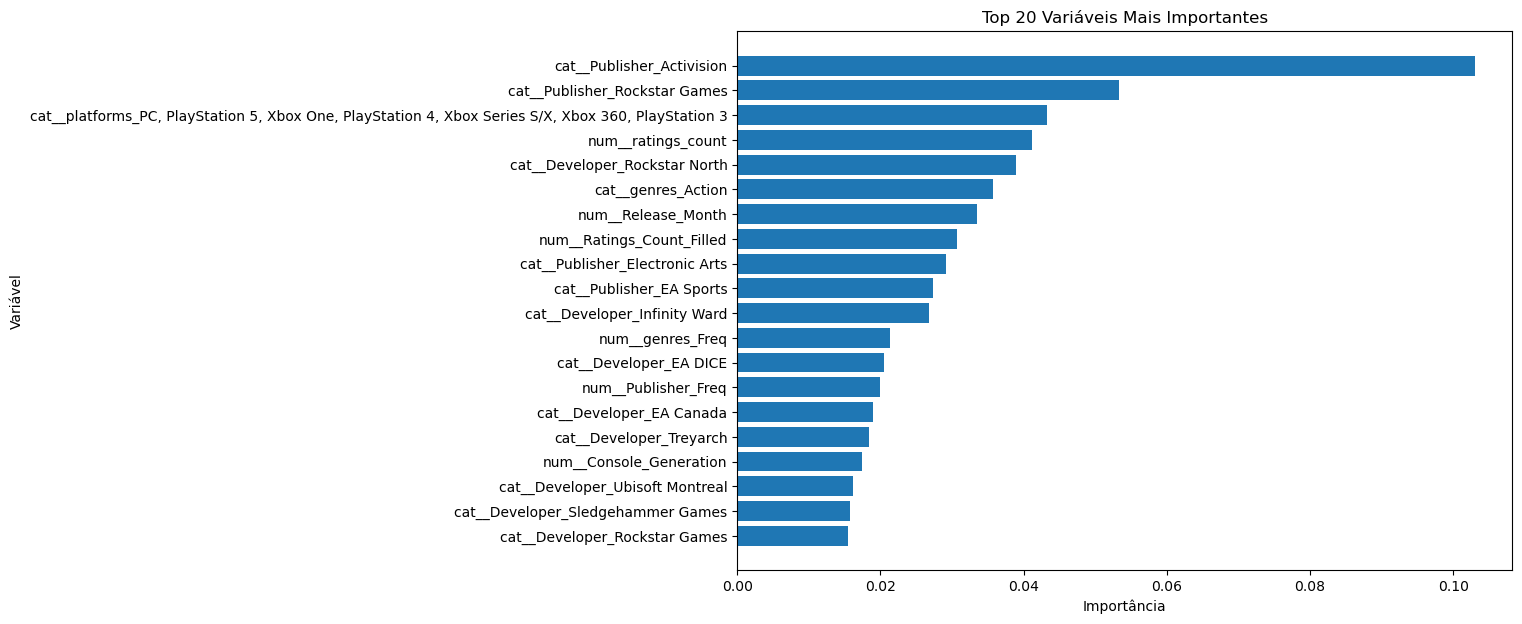

In [86]:
modelo_final = melhor_modelo.named_steps["model"]
nomes_variaveis = melhor_modelo.named_steps["prep"].get_feature_names_out()

if hasattr(modelo_final, "feature_importances_"):
    importancias = pd.Series(
        modelo_final.feature_importances_,
        index=nomes_variaveis
    ).sort_values(ascending=False)
    
    top_20_importancias = importancias.head(20).reset_index()
    top_20_importancias.columns = ["Variável", "Importância"]
    display(top_20_importancias)
    
    plt.figure(figsize=(10, 7))
    plt.barh(top_20_importancias["Variável"][::-1], top_20_importancias["Importância"][::-1])
    plt.title("Top 20 Variáveis Mais Importantes")
    plt.xlabel("Importância")
    plt.ylabel("Variável")
    plt.show()
else:
    print("O modelo final não possui atributo feature_importances_.")

**A análise da importância das variáveis demonstra quais atributos tiveram maior influência na previsão das vendas globais. Essas informações ajudam na interpretação do modelo e na identificação dos fatores que mais impactam o sucesso comercial de um jogo.**

# Top 10 Jogos mais vendidos

In [87]:
top10_jogos = df.sort_values(by="Total Sales", ascending=False).head(10)

top10_jogos[["Name", "Console", "Publisher", "Developer", "Total Sales"]]

,Name,Console,Publisher,Developer,Total Sales
0,Grand Theft Auto V,PS3,Rockstar Games,Rockstar North,20320000.0
1,Grand Theft Auto V,PS4,Rockstar Games,Rockstar North,19390000.0
2,Call of Duty: Black Ops 3,PS4,Activision,Treyarch,15090000.0
3,Red Dead Redemption 2,PS4,Rockstar Games,Rockstar Games,13940000.0
4,Call of Duty: Black Ops II,PS3,Activision,Treyarch,13800000.0
5,Call of Duty: WWII,PS4,Activision,Sledgehammer Games,13400000.0
6,Call of Duty: Modern Warfare 3,PS3,Activision,Infinity Ward,13350000.0
7,Call of Duty: Black Ops,PS3,Activision,Treyarch,12670000.0
8,FIFA 18,PS4,EA Sports,EA Vancouver,11800000.0
9,FIFA 17,PS4,Electronic Arts,EA Canada,10940000.0


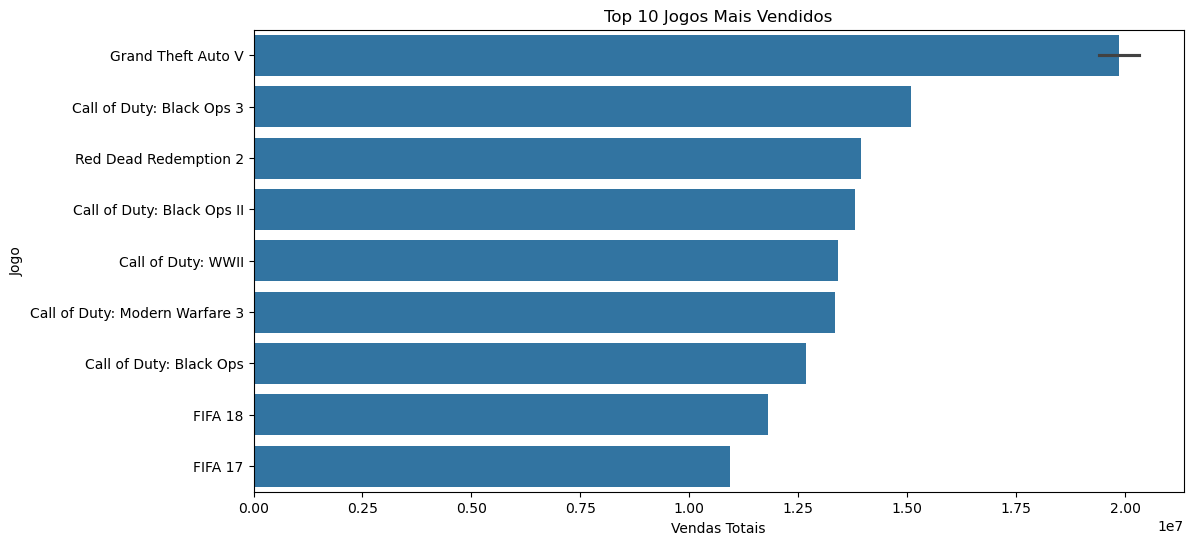

In [88]:
# Visualizar top 10 jogos mais vendidos
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top10_jogos,
    x="Total Sales",
    y="Name"
)

plt.title("Top 10 Jogos Mais Vendidos")
plt.xlabel("Vendas Totais")
plt.ylabel("Jogo")
plt.show()

**Identificar os jogos mais vendidos ajuda a entender quais títulos tiveram maior sucesso comercial.**

**Essa análise permite observar características comuns entre os grandes sucessos, como publisher, desenvolvedora, plataforma e gênero. Esses padrões podem indicar fatores importantes para prever o desempenho de novos lançamentos.**

# Publisher que mais vende

In [91]:
top_publishers = (df.groupby("Publisher")["Total Sales"].sum().sort_values(ascending=False).head(10))
top_publishers

Publisher
Activision                                205940000.0
Electronic Arts                           153760000.0
EA Sports                                 129990000.0
Ubisoft                                   128370000.0
Sony Computer Entertainment               103700000.0
Rockstar Games                             82280000.0
Square Enix                                58150000.0
Sony Interactive Entertainment             57870000.0
Bethesda Softworks                         53740000.0
Warner Bros. Interactive Entertainment     51850000.0
Name: Total Sales, dtype: float64

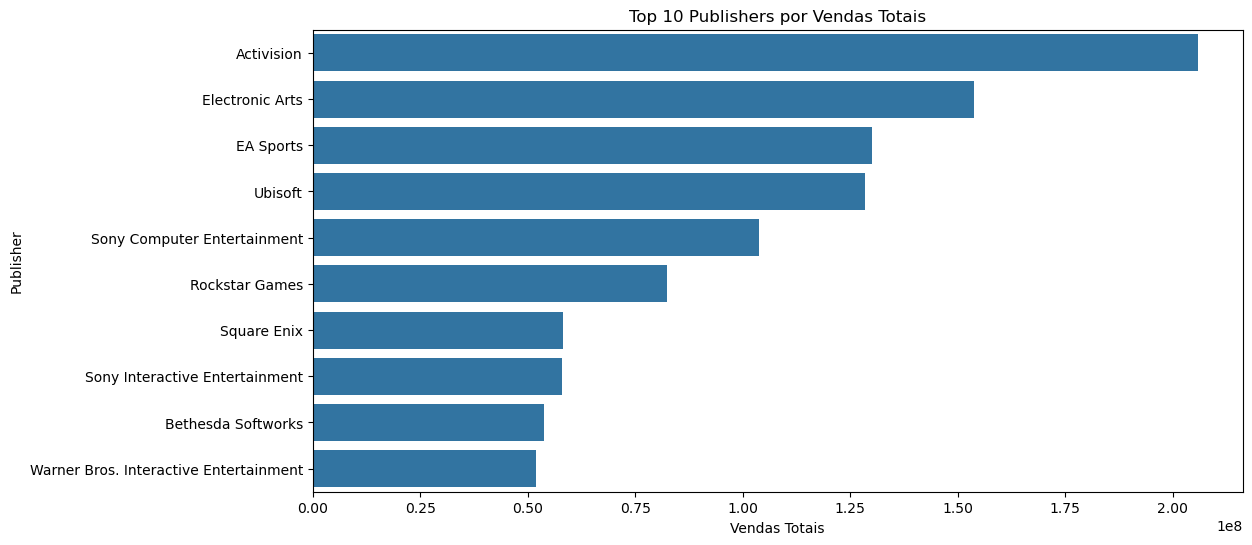

In [92]:
# Gráfico dos publishers com maiores vendas
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_publishers.values,
    y=top_publishers.index
)

plt.title("Top 10 Publishers por Vendas Totais")
plt.xlabel("Vendas Totais")
plt.ylabel("Publisher")
plt.show()

**O publisher pode influenciar diretamente o desempenho comercial de um jogo.**

**Empresas maiores geralmente possuem maior capacidade de investimento em marketing, distribuição global, relacionamento com varejistas e reconhecimento de marca. Por isso, essa variável pode ser relevante para prever o potencial de vendas de um jogo.**

# Desenvolvedoras com maiores vendas

In [93]:
# Top 10 desenvolvedoras por vendas totais
top_developers = (df.groupby("Developer")["Total Sales"].sum().sort_values(ascending=False).head(10))
top_developers

Developer
EA Canada           90580000.0
Ubisoft Montreal    70260000.0
Treyarch            61580000.0
Infinity Ward       54150000.0
Rockstar North      52370000.0
EA Tiburon          44720000.0
Visual Concepts     35670000.0
EA DICE             32650000.0
Naughty Dog         32110000.0
Capcom              31960000.0
Name: Total Sales, dtype: float64

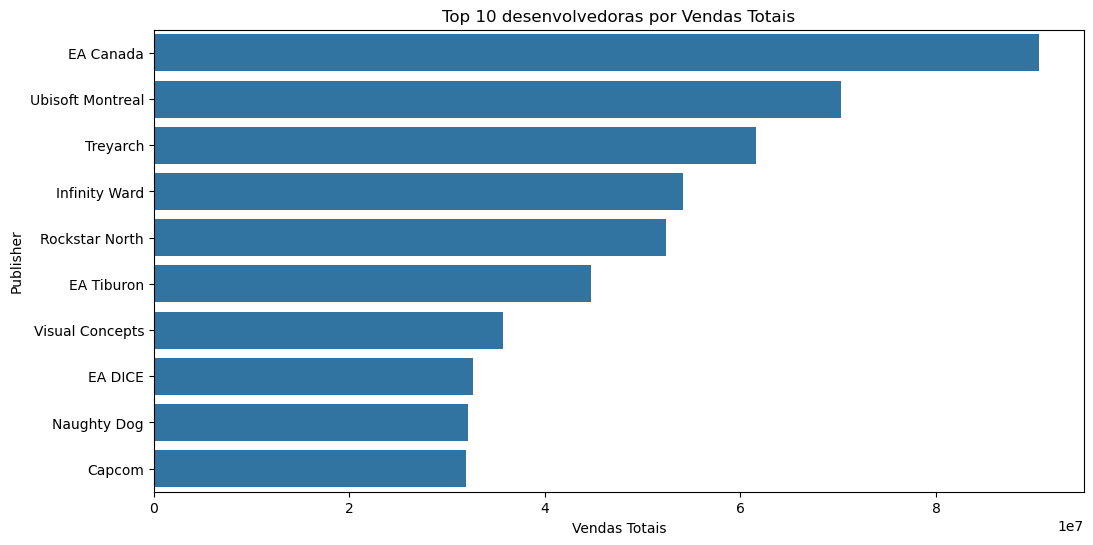

In [94]:
# Gráfico das Desenvolvedoras com maiores vendas
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_developers.values,
    y=top_developers.index
)

plt.title("Top 10 desenvolvedoras por Vendas Totais")
plt.xlabel("Vendas Totais")
plt.ylabel("Publisher")
plt.show()

**A desenvolvedora é relevante porque representa a empresa responsável pela criação do jogo.** 

**Estúdios com histórico de sucesso podem ter maior reputação, qualidade técnica, base de fãs e capacidade de gerar expectativa antes do lançamento. Isso pode impactar diretamente as vendas..** 

# Gêneros mais vendidos

In [95]:
# Top 10 gêneros por vendas totais
top_generos = (
    df.groupby("genres")["Total Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_generos

genres
Shooter, Action       235200000.0
Sports                153380000.0
Action                147170000.0
Adventure, Action      91820000.0
Action, RPG            71900000.0
Shooter                37210000.0
RPG                    30460000.0
Arcade                 25720000.0
Racing, Arcade         22210000.0
Simulation, Sports     17760000.0
Name: Total Sales, dtype: float64

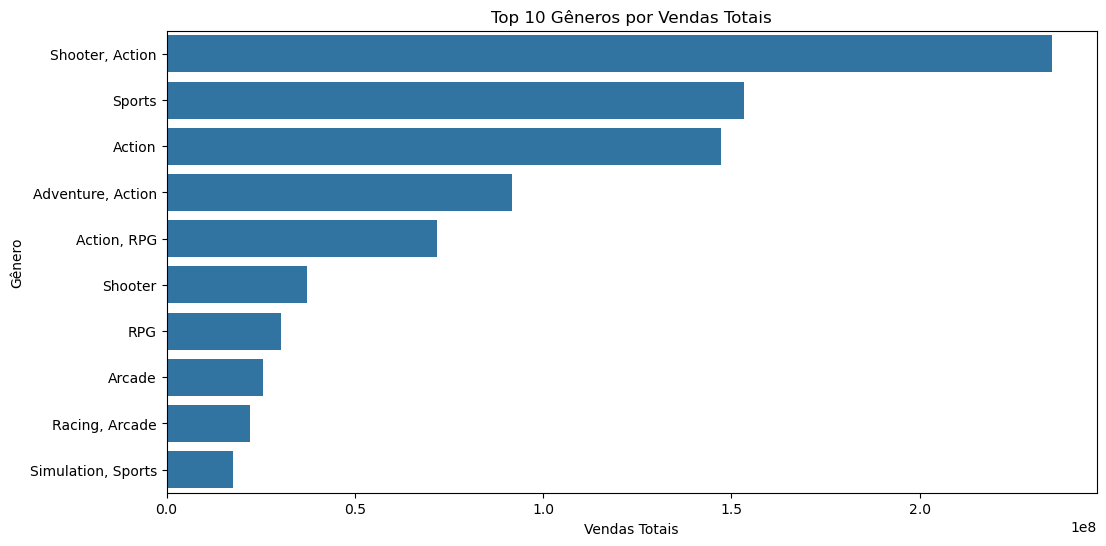

In [96]:
# Gráfico de gêneros mais vendidos
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_generos.values,
    y=top_generos.index
)

plt.title("Top 10 Gêneros por Vendas Totais")
plt.xlabel("Vendas Totais")
plt.ylabel("Gênero")
plt.show()

**O gênero é uma das variáveis mais importantes na previsão de vendas, pois diferentes tipos de jogos possuem comportamentos de mercado distintos.**

**Jogos de ação, aventura, esportes, RPG ou corrida podem ter públicos muito diferentes. Cada gênero possui comportamento de consumo específico, o que torna essa variável relevante para explicar diferenças no volume de vendas.**

# Relação entre Metacritic e vendas

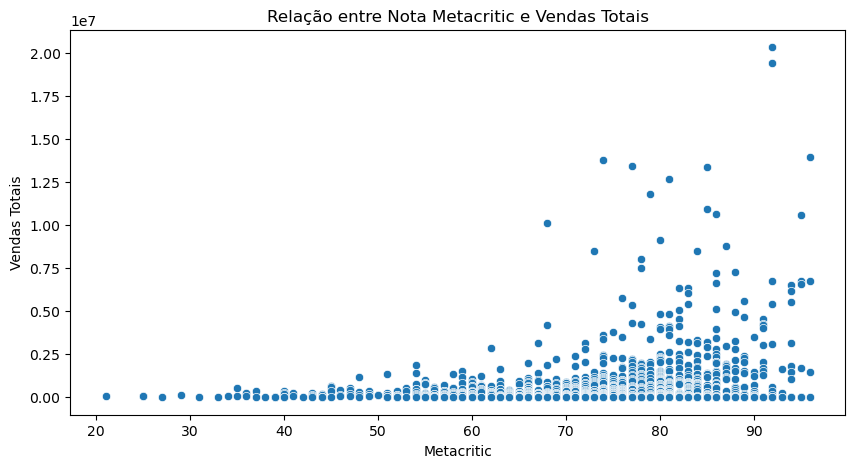

In [97]:
# Gráfico de dispersão entre nota Metacritic e vendas totais
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df,
    x="metacritic",
    y="Total Sales"
)

plt.title("Relação entre Nota Metacritic e Vendas Totais")
plt.xlabel("Metacritic")
plt.ylabel("Vendas Totais")
plt.show()

In [98]:
# Correlação entre Metacritic e vendas
correlacao_metacritic = df[["metacritic", "Total Sales"]].corr()

correlacao_metacritic

,metacritic,Total Sales
metacritic,1.000000,0.240655
Total Sales,0.240655,1.000000


**A nota do Metacritic representa a avaliação da crítica especializada.**

**Essa variável pode ser relevante porque jogos bem avaliados tendem a gerar maior confiança no consumidor, maior divulgação espontânea e melhor aceitação no mercado. Por isso, analisar sua relação com vendas ajuda a verificar se a qualidade percebida pela crítica influencia o desempenho comercial.**

# Relação entre avaliações dos usuários e vendas

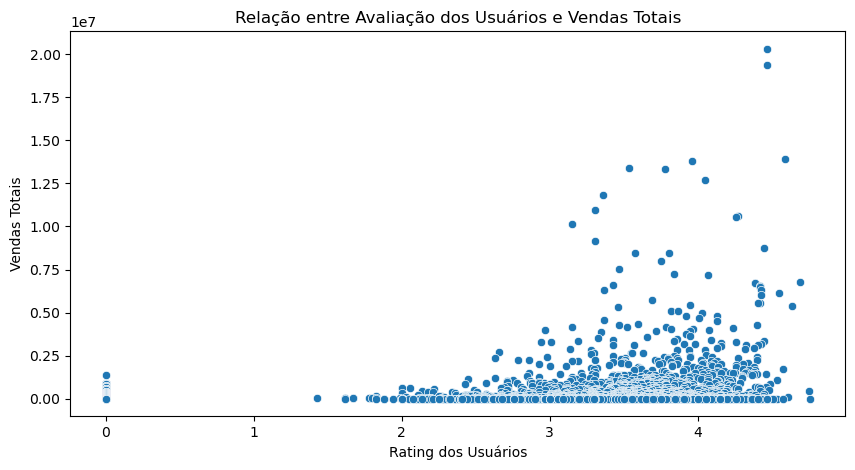

In [99]:
# Gráfico de dispersão entre avaliação dos usuários e vendas totais
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df,
    x="rating",
    y="Total Sales"
)

plt.title("Relação entre Avaliação dos Usuários e Vendas Totais")
plt.xlabel("Rating dos Usuários")
plt.ylabel("Vendas Totais")
plt.show()

In [100]:
# Correlação entre rating e vendas
correlacao_rating = df[["rating", "Total Sales"]].corr()

correlacao_rating

,rating,Total Sales
rating,1.000000,0.211558
Total Sales,0.211558,1.000000


**A avaliação dos usuários mostra a percepção dos jogadores em relação ao jogo.**

**Essa informação é importante porque a opinião dos consumidores pode influenciar diretamente a decisão de compra de outros jogadores. Uma boa avaliação pode aumentar a confiança no produto e contribuir para maiores vendas.**

# Vendas por região

In [101]:
# Somar vendas por região
vendas_regiao = df[["NA Sales", "PAL Sales", "Japan Sales", "Other Sales"]].sum()

vendas_regiao

NA Sales       584740000.0
PAL Sales      580910000.0
Japan Sales    108130000.0
Other Sales    219670000.0
dtype: float64

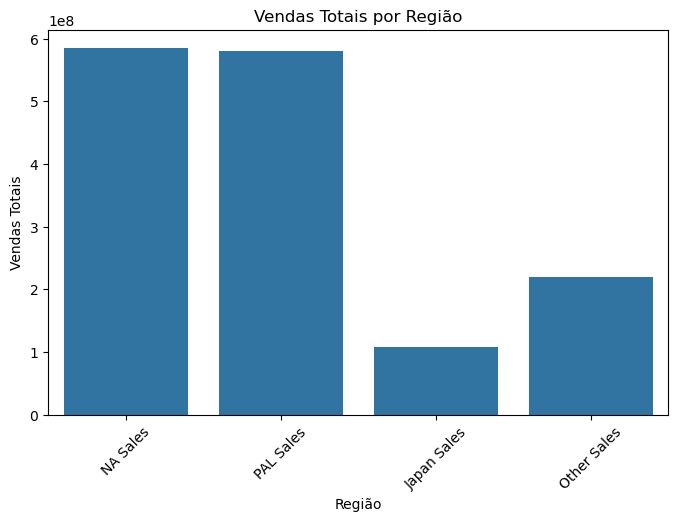

In [102]:
# Gráfico de vendas por região
plt.figure(figsize=(8, 5))
sns.barplot(
    x=vendas_regiao.index,
    y=vendas_regiao.values
)

plt.title("Vendas Totais por Região")
plt.xlabel("Região")
plt.ylabel("Vendas Totais")
plt.xticks(rotation=45)
plt.show()

**A análise regional permite entender quais mercados possuem maior participação nas vendas globais.**

**Essa informação é importante para decisões de marketing, distribuição e localização de jogos. Caso uma região represente grande parte das vendas, a empresa pode priorizar campanhas, estoque e estratégias comerciais naquele mercado.**

# Vendas ao longo dos anos

In [103]:
# Vendas totais por ano de lançamento
vendas_ano = (df.groupby("Release Year")["Total Sales"].sum().sort_index())
vendas_ano

Release Year
2006.0     10670000.0
2007.0     61570000.0
2008.0    102880000.0
2009.0    107790000.0
2010.0    121990000.0
2011.0    155480000.0
2012.0    105290000.0
2013.0    122910000.0
2014.0    165170000.0
2015.0    152640000.0
2016.0    137890000.0
2017.0    137570000.0
2018.0    109020000.0
2019.0      1230000.0
2020.0       570000.0
2021.0            0.0
2022.0            0.0
2023.0            0.0
Name: Total Sales, dtype: float64

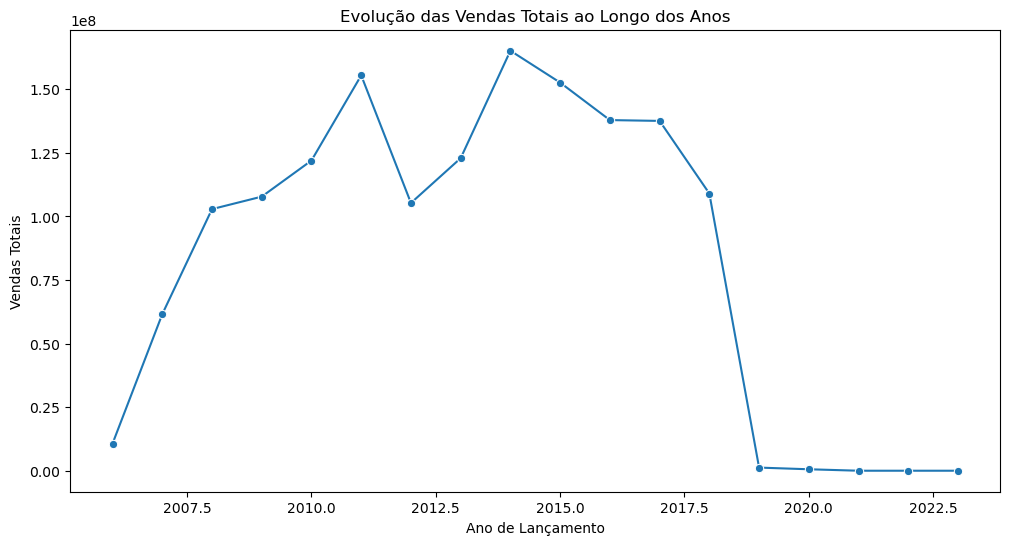

In [104]:
# Gráfico de vendas ao longo dos anos
plt.figure(figsize=(12, 6))
sns.lineplot(
    x=vendas_ano.index,
    y=vendas_ano.values,
    marker="o"
)

plt.title("Evolução das Vendas Totais ao Longo dos Anos")
plt.xlabel("Ano de Lançamento")
plt.ylabel("Vendas Totais")
plt.show()

**O ano de lançamento é relevante porque o mercado de games muda com o tempo.**

**Cada geração de console possui um ciclo de vida, com períodos de crescimento, maturidade e queda. Além disso, mudanças tecnológicas, novos hábitos de consumo e crescimento das vendas digitais podem afetar o desempenho dos jogos ao longo dos anos.**